In [ ]:
!nvidia-smi

Tue May  5 10:15:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics roboflow pyyaml pandas matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.0 MB/s eta 0:00:00


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/varroa_bitirme"
RAW_DIR = f"{PROJECT_DIR}/raw_datasets"
PROCESSED_DIR = f"{PROJECT_DIR}/processed_datasets"
RUNS_DIR = f"{PROJECT_DIR}/runs"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)

print("Proje klasörü hazır:", PROJECT_DIR)

Proje klasörü hazır: /content/drive/MyDrive/varroa_bitirme


In [ ]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "wdlFpC4D0ndwhH5xoJVm"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

In [ ]:
import os

os.chdir(RAW_DIR)

project_varroa = rf.workspace("varroa-j8231").project("varroa-bxxhd")
dataset_varroa = project_varroa.version(1).download("yolov8")

print(dataset_varroa.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Varroa-1 in yolov8:: 100%|██████████| 26996/26996 [05:23<00:00, 83.39it/s]


/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-1


In [ ]:
os.chdir(RAW_DIR)

project_honeybee = rf.workspace("honeybee").project("honeybee_varroamite")
dataset_honeybee = project_honeybee.version(5).download("yolov8")

print(dataset_honeybee.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to HoneyBee_VarroaMite-5 in yolov8:: 100%|██████████| 28400/28400 [06:06<00:00, 77.54it/s]

/content/drive/MyDrive/varroa_bitirme/raw_datasets/HoneyBee_VarroaMite-5


In [ ]:
os.chdir(RAW_DIR)

project_external = rf.workspace("varroa-virus-detection").project("varroa-mites-detector")
dataset_external = project_external.version(2).download("yolov8")

print(dataset_external.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Varroa-Mites-Detector-2 in yolov8:: 100%|██████████| 11888/11888 [02:32<00:00, 77.74it/s] 

/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-Mites-Detector-2


In [ ]:
import os

for root, dirs, files in os.walk(RAW_DIR):
    level = root.replace(RAW_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        dirs[:] = []

raw_datasets/
  Varroa-1/
    test/
    train/
    valid/
  HoneyBee_VarroaMite-5/
    test/
    train/
    valid/
  Varroa-Mites-Detector-2/
    test/
    train/
    valid/


In [ ]:
import glob

yaml_files = glob.glob(f"{RAW_DIR}/**/data.yaml", recursive=True)

print("Bulunan data.yaml dosyaları:")
for y in yaml_files:
    print(y)

print("Toplam:", len(yaml_files))

Bulunan data.yaml dosyaları:
/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-1/data.yaml
/content/drive/MyDrive/varroa_bitirme/raw_datasets/HoneyBee_VarroaMite-5/data.yaml
/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-Mites-Detector-2/data.yaml
Toplam: 3


In [ ]:
import glob
import yaml
import os

yaml_files = glob.glob(f"{RAW_DIR}/**/data.yaml", recursive=True)

print("Bulunan data.yaml dosyaları:")
for y in yaml_files:
    print(y)

Bulunan data.yaml dosyaları:
/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-1/data.yaml
/content/drive/MyDrive/varroa_bitirme/raw_datasets/HoneyBee_VarroaMite-5/data.yaml
/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-Mites-Detector-2/data.yaml


In [ ]:
VARROA_RAW = "/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-1"
HONEYBEE_RAW = "/content/drive/MyDrive/varroa_bitirme/raw_datasets/HoneyBee_VarroaMite-5"
EXTERNAL_RAW = "/content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-Mites-Detector-2"

print("VARROA_RAW:", VARROA_RAW)
print("HONEYBEE_RAW:", HONEYBEE_RAW)
print("EXTERNAL_RAW:", EXTERNAL_RAW)

VARROA_RAW: /content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-1
HONEYBEE_RAW: /content/drive/MyDrive/varroa_bitirme/raw_datasets/HoneyBee_VarroaMite-5
EXTERNAL_RAW: /content/drive/MyDrive/varroa_bitirme/raw_datasets/Varroa-Mites-Detector-2


In [ ]:
import os

print(os.path.exists(VARROA_RAW + "/data.yaml"))
print(os.path.exists(HONEYBEE_RAW + "/data.yaml"))
print(os.path.exists(EXTERNAL_RAW + "/data.yaml"))

True
True
True


In [ ]:
import os
import shutil
from pathlib import Path
import yaml

def prepare_single_class_yolo_dataset(
    src_dir,
    dst_dir,
    source_varroa_class_ids,
    new_class_name="varroa",
    min_wh=1e-6,
    max_area=0.60
):
    """
    YOLO veri setini tek sınıfa indirir.
    Sadece source_varroa_class_ids içindeki class id'leri korur.
    Korunan class id'leri 0 olarak yeniden yazar.
    Bozuk bbox satırlarını siler.
    """
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    if dst_dir.exists():
        shutil.rmtree(dst_dir)

    dst_dir.mkdir(parents=True, exist_ok=True)

    stats = {
        "copied_images": 0,
        "total_label_lines": 0,
        "kept_label_lines": 0,
        "removed_wrong_class": 0,
        "removed_invalid_bbox": 0,
        "empty_labels_after_cleaning": 0
    }

    for split in ["train", "valid", "test"]:
        src_img_dir = src_dir / split / "images"
        src_lbl_dir = src_dir / split / "labels"

        dst_img_dir = dst_dir / split / "images"
        dst_lbl_dir = dst_dir / split / "labels"

        dst_img_dir.mkdir(parents=True, exist_ok=True)
        dst_lbl_dir.mkdir(parents=True, exist_ok=True)

        image_paths = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            image_paths.extend(list(src_img_dir.glob(ext)))

        for img_path in image_paths:
            shutil.copy2(img_path, dst_img_dir / img_path.name)
            stats["copied_images"] += 1

            label_path = src_lbl_dir / f"{img_path.stem}.txt"
            new_label_path = dst_lbl_dir / f"{img_path.stem}.txt"

            new_lines = []

            if label_path.exists():
                lines = label_path.read_text().strip().splitlines()

                for line in lines:
                    if not line.strip():
                        continue

                    parts = line.strip().split()
                    if len(parts) != 5:
                        stats["removed_invalid_bbox"] += 1
                        continue

                    cls_id = int(float(parts[0]))
                    x, y, w, h = map(float, parts[1:])

                    stats["total_label_lines"] += 1

                    if cls_id not in source_varroa_class_ids:
                        stats["removed_wrong_class"] += 1
                        continue

                    area = w * h

                    if w <= min_wh or h <= min_wh or area <= min_wh or area > max_area:
                        stats["removed_invalid_bbox"] += 1
                        continue

                    # Güvenlik için koordinatları 0-1 aralığında tutalım
                    x = min(max(x, 0.0), 1.0)
                    y = min(max(y, 0.0), 1.0)
                    w = min(max(w, 0.0), 1.0)
                    h = min(max(h, 0.0), 1.0)

                    new_lines.append(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
                    stats["kept_label_lines"] += 1

            if len(new_lines) == 0:
                stats["empty_labels_after_cleaning"] += 1

            new_label_path.write_text("\n".join(new_lines))

    data_yaml = {
        "path": str(dst_dir),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": {
            0: new_class_name
        }
    }

    with open(dst_dir / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)

    return stats

In [ ]:
VARROA_PROCESSED = f"{PROCESSED_DIR}/varroa_dataset_single_class"

stats_varroa = prepare_single_class_yolo_dataset(
    src_dir=VARROA_RAW,
    dst_dir=VARROA_PROCESSED,
    source_varroa_class_ids=[1],
    max_area=0.35
)

stats_varroa

{'copied_images': 13492,
 'total_label_lines': 18700,
 'kept_label_lines': 5141,
 'removed_wrong_class': 13551,
 'removed_invalid_bbox': 8,
 'empty_labels_after_cleaning': 9155}

In [ ]:
HONEYBEE_PROCESSED = f"{PROCESSED_DIR}/honeybee_varroamite_single_class"

stats_honeybee = prepare_single_class_yolo_dataset(
    src_dir=HONEYBEE_RAW,
    dst_dir=HONEYBEE_PROCESSED,
    source_varroa_class_ids=[0],
    max_area=0.60
)

stats_honeybee

{'copied_images': 14194,
 'total_label_lines': 10379,
 'kept_label_lines': 10358,
 'removed_wrong_class': 0,
 'removed_invalid_bbox': 21,
 'empty_labels_after_cleaning': 5115}

In [ ]:
EXTERNAL_PROCESSED = f"{PROCESSED_DIR}/external_varroa_mites_detector_single_class"

stats_external = prepare_single_class_yolo_dataset(
    src_dir=EXTERNAL_RAW,
    dst_dir=EXTERNAL_PROCESSED,
    source_varroa_class_ids=[0],
    max_area=0.35
)

stats_external

{'copied_images': 5938,
 'total_label_lines': 2718,
 'kept_label_lines': 2718,
 'removed_wrong_class': 0,
 'removed_invalid_bbox': 0,
 'empty_labels_after_cleaning': 3791}

In [ ]:
from pathlib import Path

def count_dataset(dataset_dir):
    dataset_dir = Path(dataset_dir)
    result = {}

    for split in ["train", "valid", "test"]:
        img_dir = dataset_dir / split / "images"
        lbl_dir = dataset_dir / split / "labels"

        images = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            images.extend(list(img_dir.glob(ext)))

        labels = list(lbl_dir.glob("*.txt"))

        bbox_count = 0
        empty_count = 0

        for label in labels:
            text = label.read_text().strip()
            if text == "":
                empty_count += 1
            else:
                bbox_count += len(text.splitlines())

        result[split] = {
            "images": len(images),
            "labels": len(labels),
            "bbox_count": bbox_count,
            "empty_labels": empty_count
        }

    return result

print("Varroa Dataset:")
print(count_dataset(VARROA_PROCESSED))

print("\nHoneyBee VarroaMite:")
print(count_dataset(HONEYBEE_PROCESSED))

print("\nExternal Validation:")
print(count_dataset(EXTERNAL_PROCESSED))

Varroa Dataset:
{'train': {'images': 8217, 'labels': 8217, 'bbox_count': 3050, 'empty_labels': 5522}, 'valid': {'images': 1867, 'labels': 1867, 'bbox_count': 644, 'empty_labels': 1441}, 'test': {'images': 3408, 'labels': 3408, 'bbox_count': 1447, 'empty_labels': 2192}}

HoneyBee VarroaMite:
{'train': {'images': 12614, 'labels': 12614, 'bbox_count': 9216, 'empty_labels': 4556}, 'valid': {'images': 790, 'labels': 790, 'bbox_count': 570, 'empty_labels': 273}, 'test': {'images': 790, 'labels': 790, 'bbox_count': 572, 'empty_labels': 286}}

External Validation:
{'train': {'images': 4749, 'labels': 4749, 'bbox_count': 2138, 'empty_labels': 3058}, 'valid': {'images': 593, 'labels': 593, 'bbox_count': 284, 'empty_labels': 375}, 'test': {'images': 596, 'labels': 596, 'bbox_count': 296, 'empty_labels': 358}}


In [ ]:
from pathlib import Path

def check_label_classes(dataset_dir):
    dataset_dir = Path(dataset_dir)
    class_ids = set()
    bad_lines = 0

    for label_path in dataset_dir.glob("**/labels/*.txt"):
        text = label_path.read_text().strip()
        if text == "":
            continue

        for line in text.splitlines():
            parts = line.split()
            if len(parts) != 5:
                bad_lines += 1
                continue
            class_ids.add(parts[0])

    return {
        "class_ids": sorted(class_ids),
        "bad_lines": bad_lines
    }

print("Varroa:", check_label_classes(VARROA_PROCESSED))
print("HoneyBee:", check_label_classes(HONEYBEE_PROCESSED))
print("External:", check_label_classes(EXTERNAL_PROCESSED))

Varroa: {'class_ids': ['0'], 'bad_lines': 0}
HoneyBee: {'class_ids': ['0'], 'bad_lines': 0}
External: {'class_ids': ['0'], 'bad_lines': 0}


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{VARROA_PROCESSED}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="yolov8n_varroa_dataset",
    patience=20,
    device=0
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/varroa_bitirme/processed_datasets/varroa_dataset_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_varroa_dataset, nbs=64, nms=Fal

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{VARROA_PROCESSED}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="yolov8n_varroa_dataset_pilot",
    patience=10,
    device=0,
    workers=2,
    cache=True
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/varroa_bitirme/processed_datasets/varroa_dataset_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_varroa_dataset_pilot, nbs=64, nms

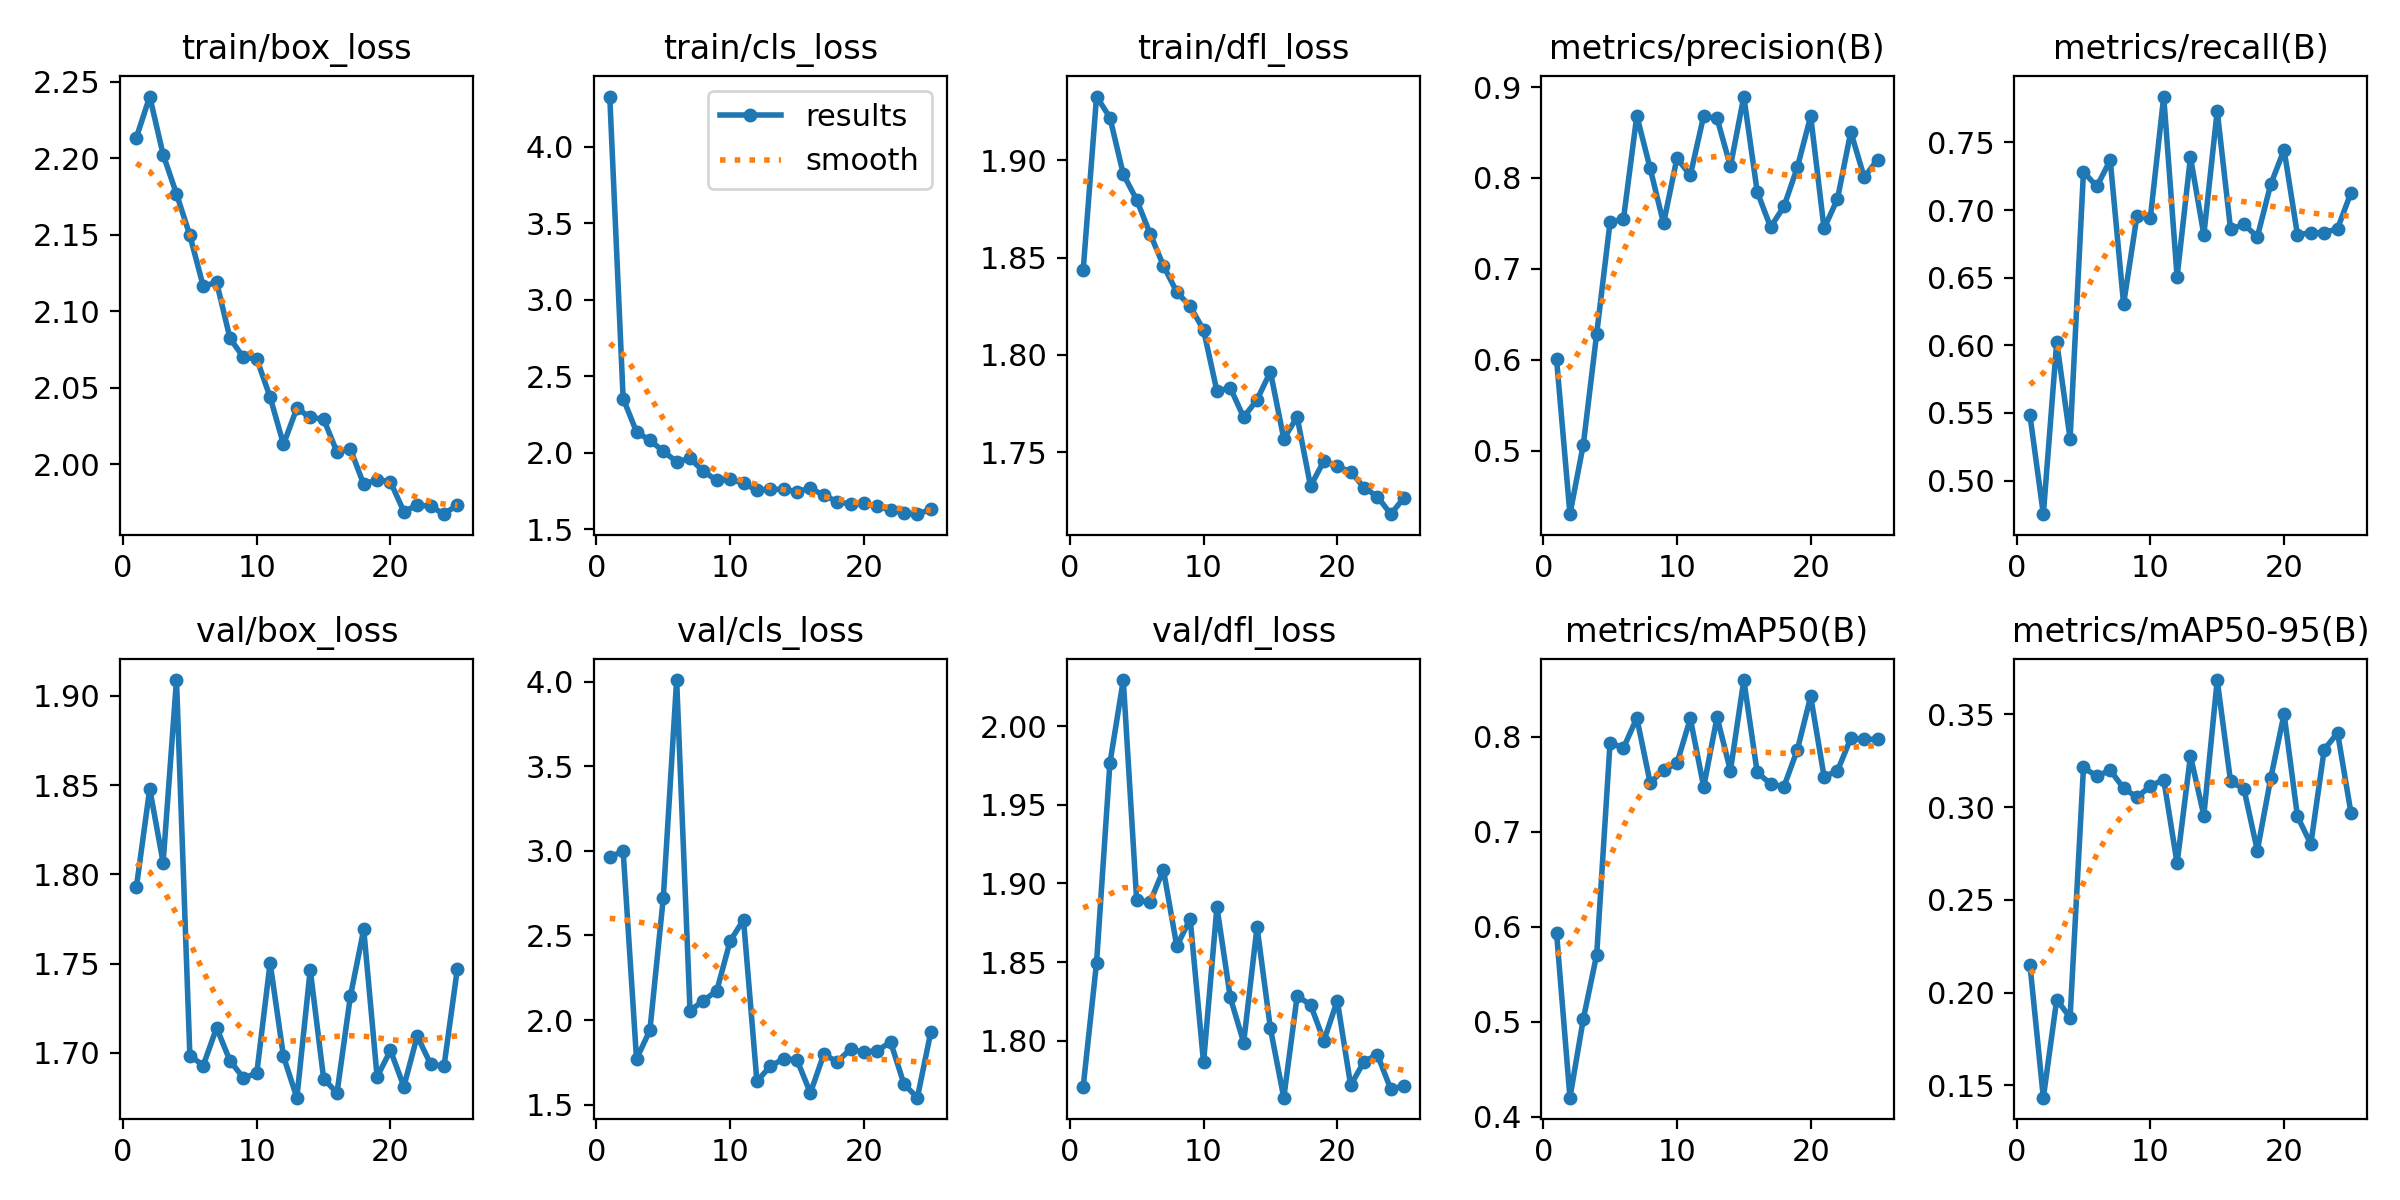

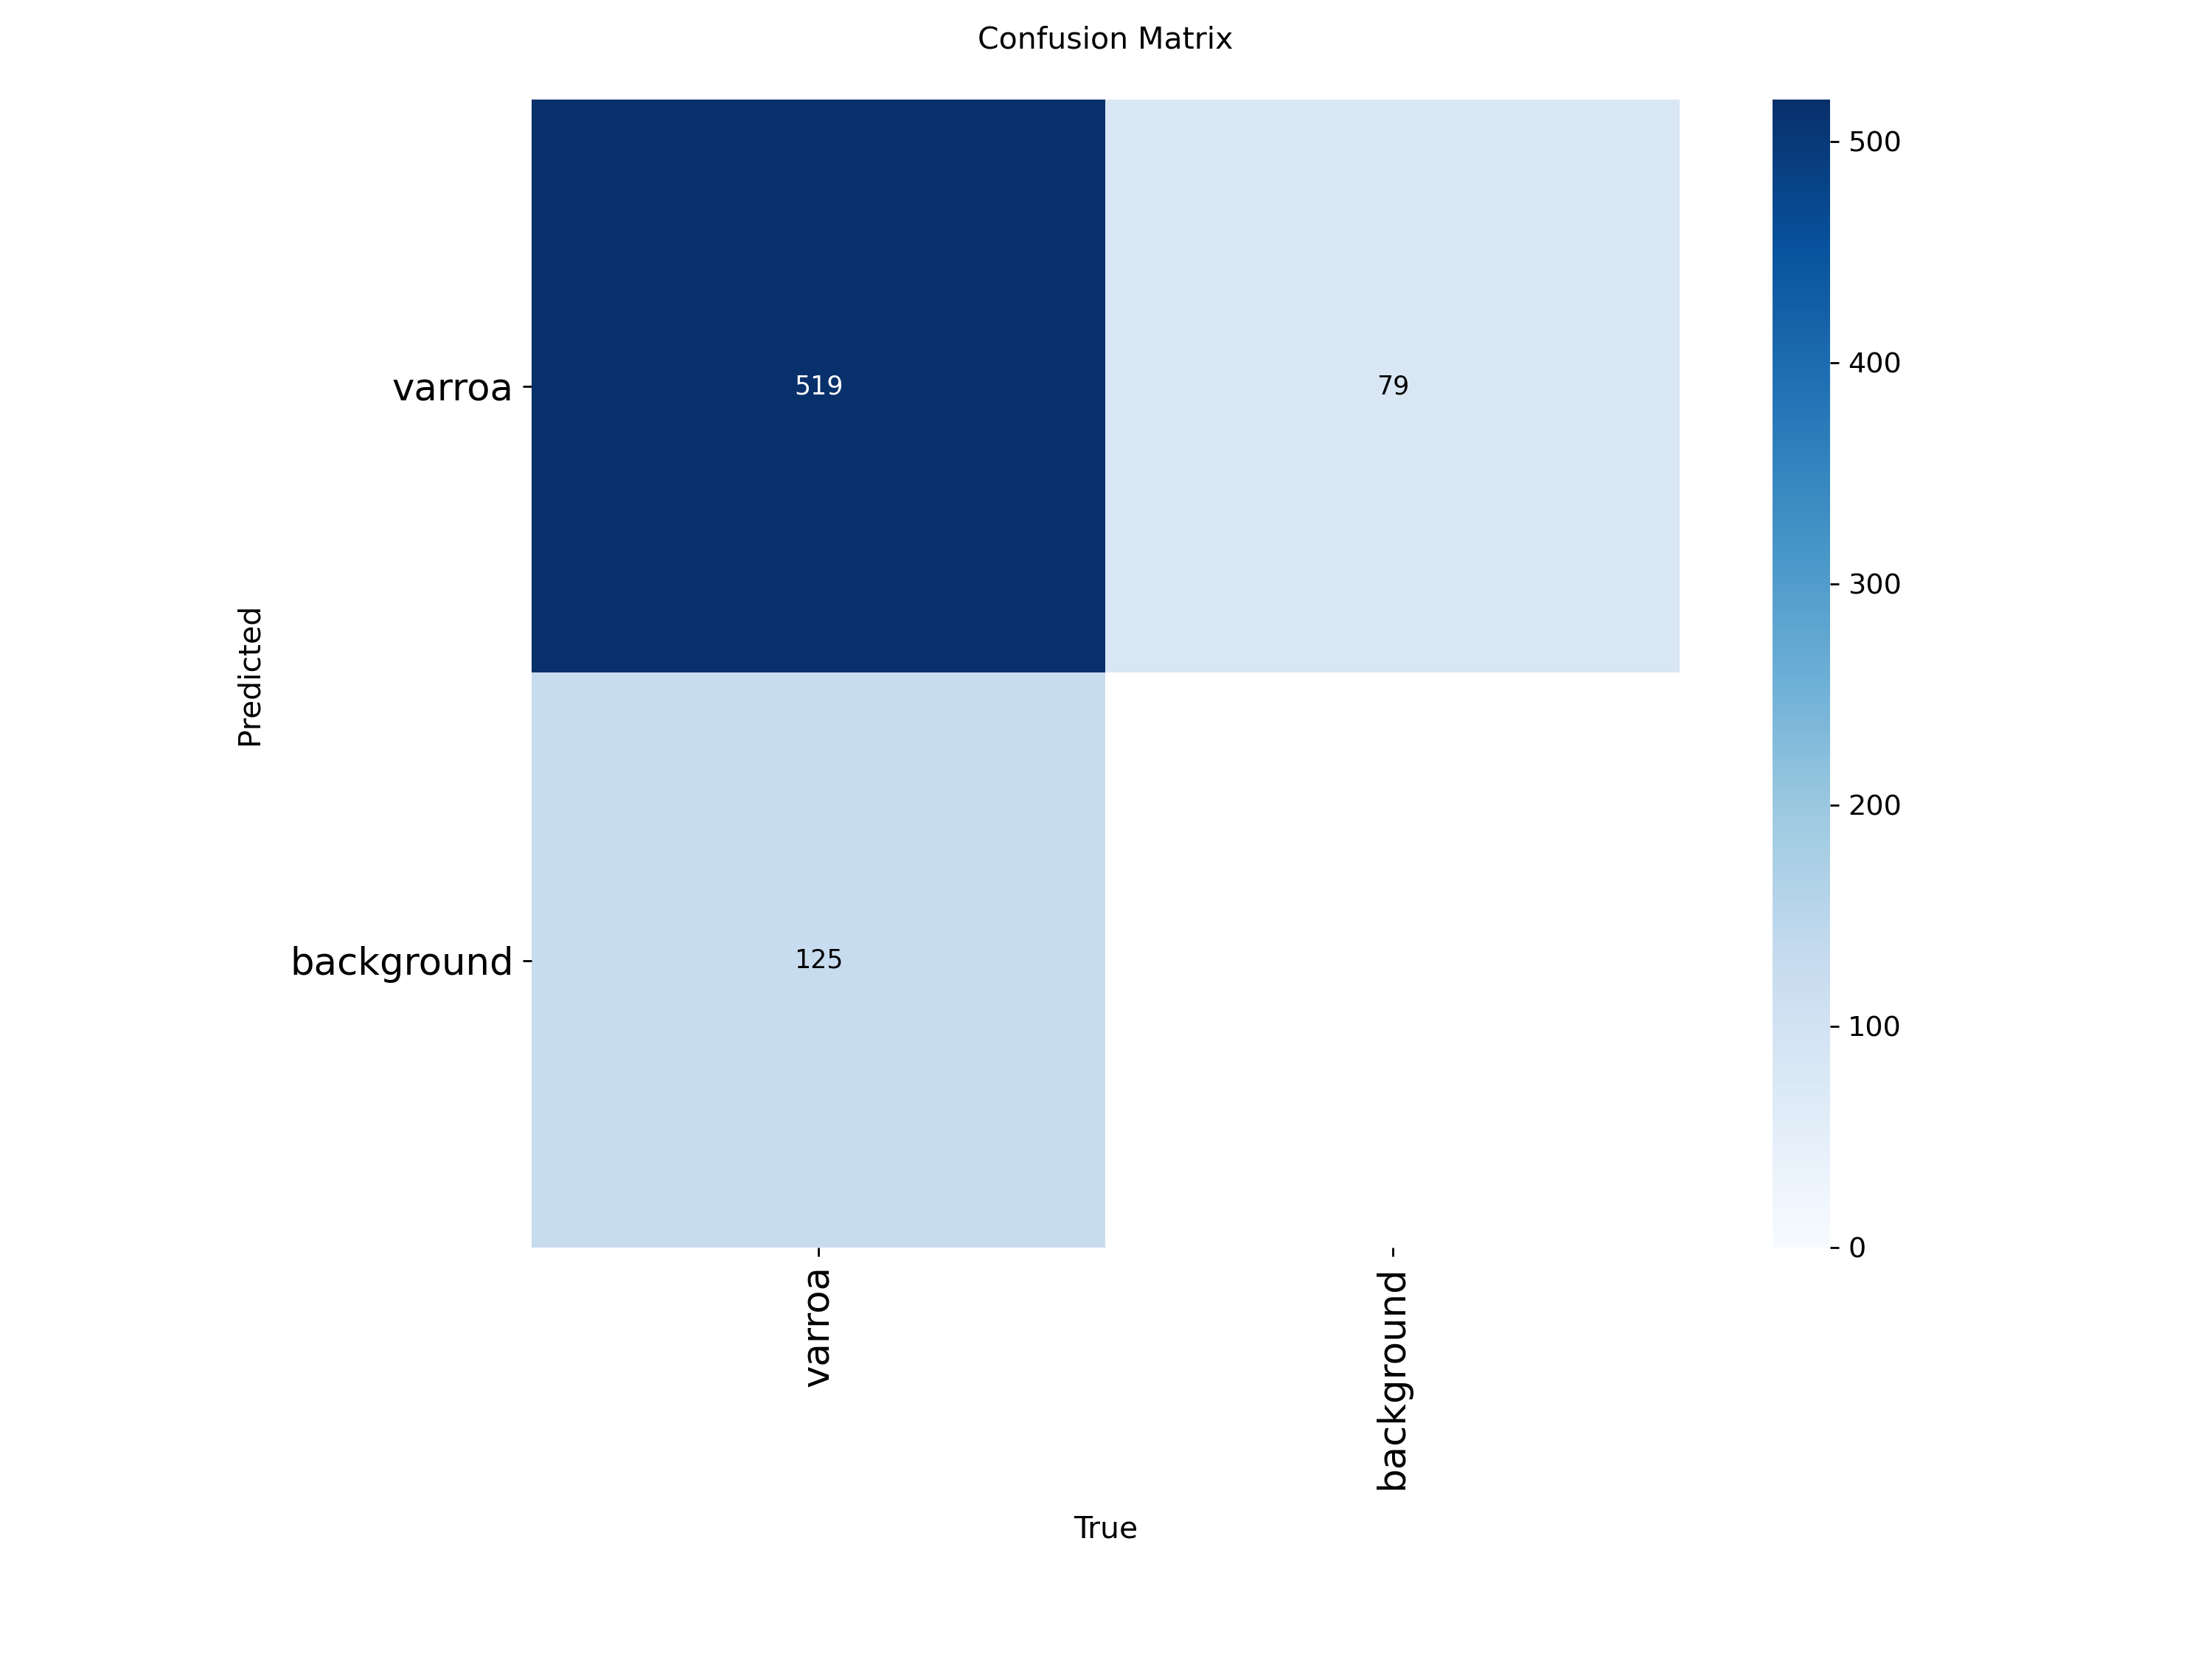

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/varroa_bitirme/runs/yolov8n_varroa_dataset_pilot/BOXPR_curve.png'

In [ ]:
from IPython.display import Image, display

run_path = "/content/drive/MyDrive/varroa_bitirme/runs/yolov8n_varroa_dataset_pilot"

display(Image(filename=f"{run_path}/results.png"))
display(Image(filename=f"{run_path}/confusion_matrix.png"))
display(Image(filename=f"{run_path}/BOXPR_curve.png"))
display(Image(filename=f"{run_path}/F1_curve.png"))

In [ ]:
import os
import shutil

SAVED_MODELS_DIR = f"{PROJECT_DIR}/saved_models"
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

src_best = f"{RUNS_DIR}/yolov8n_varroa_dataset_pilot/weights/best.pt"
dst_best = f"{SAVED_MODELS_DIR}/yolov8n_varroa_dataset_best.pt"

shutil.copy2(src_best, dst_best)

print("Model yedeklendi:")
print(dst_best)

Model yedeklendi:
/content/drive/MyDrive/varroa_bitirme/saved_models/yolov8n_varroa_dataset_best.pt


In [ ]:
from ultralytics import YOLO

model_path = f"{RUNS_DIR}/yolov8n_varroa_dataset_pilot/weights/best.pt"
model = YOLO(model_path)

external_results_yolov8_varroa = model.val(
    data=f"{EXTERNAL_PROCESSED}/data.yaml",
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="external_val_yolov8n_varroa_dataset_pilot",
    device=0
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.2±1.2 ms, read: 8.9±1.4 MB/s, size: 36.8 KB)
val: Scanning /content/drive/MyDrive/varroa_bitirme/processed_datasets/external_varroa_mites_detector_single_class/valid/labels... 593 images, 375 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 67.3it/s 8.8s
val: New cache created: /content/drive/MyDrive/varroa_bitirme/processed_datasets/external_varroa_mites_detector_single_class/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 4.3it/s 8.8s
                   all        593        284      0.817      0.549      0.629      0.222
Speed: 2.7ms preprocess, 4.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/drive/MyDrive/varroa_bitirme/runs/external_val_yolov8n_varroa_dataset_pilot


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data=f"{VARROA_PROCESSED}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="yolo26n_varroa_dataset_pilot",
    patience=10,
    device=0,
    workers=2,
    cache=True
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/varroa_bitirme/processed_datasets/varroa_dataset_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_varroa_dataset_pilot, nbs=64, nm

KeyboardInterrupt: 

In [ ]:
!nvidia-smi

Fri May  8 11:33:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics roboflow pyyaml pandas matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics

ultralytics.checks()
print("Ultralytics hazır.")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)
Ultralytics hazır.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/varroa_bitirme"

RAW_DIR = f"{PROJECT_DIR}/raw_datasets"
PROCESSED_DIR = f"{PROJECT_DIR}/processed_datasets"
RUNS_DIR = f"{PROJECT_DIR}/runs"

VARROA_RAW = f"{RAW_DIR}/Varroa-1"
HONEYBEE_RAW = f"{RAW_DIR}/HoneyBee_VarroaMite-5"
EXTERNAL_RAW = f"{RAW_DIR}/Varroa-Mites-Detector-2"

VARROA_PROCESSED = f"{PROCESSED_DIR}/varroa_dataset_single_class"
HONEYBEE_PROCESSED = f"{PROCESSED_DIR}/honeybee_varroamite_single_class"
EXTERNAL_PROCESSED = f"{PROCESSED_DIR}/external_varroa_mites_detector_single_class"

os.makedirs(RUNS_DIR, exist_ok=True)

print("Yollar tanımlandı.")
print("PROJECT_DIR:", PROJECT_DIR)

Yollar tanımlandı.
PROJECT_DIR: /content/drive/MyDrive/varroa_bitirme


In [ ]:
import os

print("Varroa data.yaml:", os.path.exists(f"{VARROA_PROCESSED}/data.yaml"))
print("HoneyBee data.yaml:", os.path.exists(f"{HONEYBEE_PROCESSED}/data.yaml"))
print("External data.yaml:", os.path.exists(f"{EXTERNAL_PROCESSED}/data.yaml"))
print("Runs klasörü:", os.path.exists(RUNS_DIR))

Varroa data.yaml: True
HoneyBee data.yaml: True
External data.yaml: True
Runs klasörü: True


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")
print("YOLO26n modeli yüklendi.")

YOLO26n modeli yüklendi.


In [ ]:
from ultralytics import YOLO
import torch

torch.cuda.empty_cache()

model = YOLO("yolo26n.pt")

results = model.train(
    data=f"{VARROA_PROCESSED}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    project=RUNS_DIR,
    name="yolo26n_varroa_dataset_pilot_short",
    patience=5,
    device=0,
    workers=1,
    cache=False,
    save=True,
    save_period=5,
    plots=True,
    exist_ok=True
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/varroa_bitirme/processed_datasets/varroa_dataset_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_varroa_dataset_pilot_short, nbs=64

KeyboardInterrupt: 

In [ ]:
import shutil
import os

LOCAL_PROJECT_DIR = "/content/varroa_bitirme_local"
LOCAL_PROCESSED_DIR = f"{LOCAL_PROJECT_DIR}/processed_datasets"
LOCAL_RUNS_DIR = f"{LOCAL_PROJECT_DIR}/runs"

os.makedirs(LOCAL_PROCESSED_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS_DIR, exist_ok=True)

# Varroa processed dataset'i local diske kopyala
src = VARROA_PROCESSED
dst = f"{LOCAL_PROCESSED_DIR}/varroa_dataset_single_class"

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)

VARROA_PROCESSED_LOCAL = dst

print("Local kopyalama tamamlandı:")
print(VARROA_PROCESSED_LOCAL)

KeyboardInterrupt: 

In [ ]:
import shutil, os

LOCAL_PROJECT_DIR = "/content/varroa_bitirme_local"

if os.path.exists(LOCAL_PROJECT_DIR):
    shutil.rmtree(LOCAL_PROJECT_DIR)

os.makedirs(LOCAL_PROJECT_DIR, exist_ok=True)

print("Local klasör temizlendi.")

Local klasör temizlendi.


In [ ]:
import shutil
import os

ZIP_PATH = "/content/varroa_dataset_single_class.zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(
    base_name="/content/varroa_dataset_single_class",
    format="zip",
    root_dir=VARROA_PROCESSED
)

print("Zip oluşturuldu:", ZIP_PATH)

Zip oluşturuldu: /content/varroa_dataset_single_class.zip


In [ ]:
import zipfile
import os

VARROA_PROCESSED_LOCAL = "/content/varroa_bitirme_local/processed_datasets/varroa_dataset_single_class"

os.makedirs(VARROA_PROCESSED_LOCAL, exist_ok=True)

with zipfile.ZipFile("/content/varroa_dataset_single_class.zip", "r") as zip_ref:
    zip_ref.extractall(VARROA_PROCESSED_LOCAL)

print("Zip açıldı:", VARROA_PROCESSED_LOCAL)

Zip açıldı: /content/varroa_bitirme_local/processed_datasets/varroa_dataset_single_class


In [ ]:
import yaml

local_yaml_path = f"{VARROA_PROCESSED_LOCAL}/data.yaml"

data_yaml = {
    "path": VARROA_PROCESSED_LOCAL,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {
        0: "varroa"
    }
}

with open(local_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("Local data.yaml güncellendi:")
print(local_yaml_path)

Local data.yaml güncellendi:
/content/varroa_bitirme_local/processed_datasets/varroa_dataset_single_class/data.yaml


In [ ]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    img_dir = Path(VARROA_PROCESSED_LOCAL) / split / "images"
    lbl_dir = Path(VARROA_PROCESSED_LOCAL) / split / "labels"

    print(split, "images:", len(list(img_dir.glob("*.*"))), "labels:", len(list(lbl_dir.glob("*.txt"))))

train images: 8217 labels: 8217
valid images: 1867 labels: 1867
test images: 3408 labels: 3408


In [ ]:
from ultralytics import YOLO
import torch

torch.cuda.empty_cache()

model = YOLO("yolo26n.pt")

results = model.train(
    data=local_yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="yolo26n_varroa_dataset_pilot_short",
    patience=5,
    device=0,
    workers=2,
    cache=True,
    save=True,
    save_period=5,
    plots=True,
    exist_ok=True
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/varroa_bitirme_local/processed_datasets/varroa_dataset_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_varroa_dataset_pilot_short, nbs=64, nms=Fa

In [ ]:
from ultralytics import YOLO

model_path = f"{RUNS_DIR}/yolo26n_varroa_dataset_pilot_short/weights/best.pt"
model = YOLO(model_path)

external_results_yolo26_varroa = model.val(
    data=f"{EXTERNAL_PROCESSED}/data.yaml",
    imgsz=640,
    batch=8,
    project=RUNS_DIR,
    name="external_val_yolo26n_varroa_dataset_pilot_short",
    device=0,
    workers=1
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.1±0.0 MB/s, size: 36.8 KB)
val: Scanning /content/drive/MyDrive/varroa_bitirme/processed_datasets/external_varroa_mites_detector_single_class/valid/labels.cache... 593 images, 375 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 146.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 4.4it/s 16.9s
                   all        593        284      0.625      0.496      0.557      0.208
Speed: 1.8ms preprocess, 5.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/drive/MyDrive/varroa_bitirme/runs/external_val_yolo26n_varroa_dataset_pilot_short


In [ ]:
!nvidia-smi

Sat May  9 11:11:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics roboflow pyyaml pandas matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics

ultralytics.checks()
print("Ultralytics hazır.")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)
Ultralytics hazır.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/varroa_bitirme"

RAW_DIR = f"{PROJECT_DIR}/raw_datasets"
PROCESSED_DIR = f"{PROJECT_DIR}/processed_datasets"
RUNS_DIR = f"{PROJECT_DIR}/runs"

VARROA_PROCESSED = f"{PROCESSED_DIR}/varroa_dataset_single_class"
HONEYBEE_PROCESSED = f"{PROCESSED_DIR}/honeybee_varroamite_single_class"
EXTERNAL_PROCESSED = f"{PROCESSED_DIR}/external_varroa_mites_detector_single_class"

os.makedirs(RUNS_DIR, exist_ok=True)

print("Yollar tanımlandı.")
print("PROJECT_DIR:", PROJECT_DIR)
print("RUNS_DIR:", RUNS_DIR)

Yollar tanımlandı.
PROJECT_DIR: /content/drive/MyDrive/varroa_bitirme
RUNS_DIR: /content/drive/MyDrive/varroa_bitirme/runs


In [ ]:
import os

print("Varroa data.yaml:", os.path.exists(f"{VARROA_PROCESSED}/data.yaml"))
print("HoneyBee data.yaml:", os.path.exists(f"{HONEYBEE_PROCESSED}/data.yaml"))
print("External data.yaml:", os.path.exists(f"{EXTERNAL_PROCESSED}/data.yaml"))

print("YOLOv8 Varroa sonucu:", os.path.exists(f"{RUNS_DIR}/yolov8n_varroa_dataset_pilot/weights/best.pt"))
print("YOLO26 Varroa sonucu:", os.path.exists(f"{RUNS_DIR}/yolo26n_varroa_dataset_pilot_short/weights/best.pt"))

Varroa data.yaml: True
HoneyBee data.yaml: True
External data.yaml: True
YOLOv8 Varroa sonucu: True
YOLO26 Varroa sonucu: True


In [ ]:
from ultralytics import YOLO
import torch

torch.cuda.empty_cache()

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{HONEYBEE_PROCESSED}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="yolov8n_honeybee_varroamite_pilot",
    patience=5,
    device=0,
    workers=1,
    cache=False,
    save=True,
    save_period=5,
    plots=True,
    exist_ok=True
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/varroa_bitirme/processed_datasets/honeybee_varroamite_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_honeybee_varroamite_pilot, n

KeyboardInterrupt: 

In [ ]:
import os
import shutil

LOCAL_PROJECT_DIR = "/content/varroa_bitirme_local"
LOCAL_PROCESSED_DIR = f"{LOCAL_PROJECT_DIR}/processed_datasets"

os.makedirs(LOCAL_PROCESSED_DIR, exist_ok=True)

print("Local klasör hazır:", LOCAL_PROCESSED_DIR)

Local klasör hazır: /content/varroa_bitirme_local/processed_datasets


In [ ]:
import shutil
import os

ZIP_PATH = "/content/honeybee_varroamite_single_class.zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(
    base_name="/content/honeybee_varroamite_single_class",
    format="zip",
    root_dir=HONEYBEE_PROCESSED
)

print("Zip oluşturuldu:", ZIP_PATH)

KeyboardInterrupt: 

In [ ]:
import os

LOCAL_PROJECT_DIR = "/content/varroa_local"
LOCAL_RAW_DIR = f"{LOCAL_PROJECT_DIR}/raw_datasets"
LOCAL_PROCESSED_DIR = f"{LOCAL_PROJECT_DIR}/processed_datasets"
LOCAL_RUNS_DIR = f"{LOCAL_PROJECT_DIR}/runs"

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_PROCESSED_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS_DIR, exist_ok=True)

os.chdir(LOCAL_RAW_DIR)

project_honeybee = rf.workspace("honeybee").project("honeybee_varroamite")
dataset_honeybee = project_honeybee.version(5).download("yolov8")

HONEYBEE_RAW_LOCAL = dataset_honeybee.location

print("HoneyBee local indirildi:")
print(HONEYBEE_RAW_LOCAL)

NameError: name 'rf' is not defined

In [ ]:
!pip install -q roboflow

In [ ]:
from roboflow import Roboflow
from getpass import getpass

ROBOFLOW_API_KEY = getpass("Roboflow API Key: ")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

print("Roboflow bağlantısı hazır.")

Roboflow API Key: ··········
Roboflow bağlantısı hazır.


In [ ]:
import os

LOCAL_PROJECT_DIR = "/content/varroa_local"
LOCAL_RAW_DIR = f"{LOCAL_PROJECT_DIR}/raw_datasets"
LOCAL_PROCESSED_DIR = f"{LOCAL_PROJECT_DIR}/processed_datasets"
LOCAL_RUNS_DIR = f"{LOCAL_PROJECT_DIR}/runs"

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_PROCESSED_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS_DIR, exist_ok=True)

os.chdir(LOCAL_RAW_DIR)

project_honeybee = rf.workspace("honeybee").project("honeybee_varroamite")
dataset_honeybee = project_honeybee.version(5).download("yolov8")

HONEYBEE_RAW_LOCAL = dataset_honeybee.location

print("HoneyBee local indirildi:")
print(HONEYBEE_RAW_LOCAL)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to HoneyBee_VarroaMite-5 in yolov8:: 100%|██████████| 28400/28400 [00:03<00:00, 8967.12it/s] 

HoneyBee local indirildi:
/content/varroa_local/raw_datasets/HoneyBee_VarroaMite-5


In [ ]:
import os

LOCAL_PROJECT_DIR = "/content/varroa_local"
LOCAL_RAW_DIR = f"{LOCAL_PROJECT_DIR}/raw_datasets"
LOCAL_PROCESSED_DIR = f"{LOCAL_PROJECT_DIR}/processed_datasets"
LOCAL_RUNS_DIR = f"{LOCAL_PROJECT_DIR}/runs"

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_PROCESSED_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS_DIR, exist_ok=True)

os.chdir(LOCAL_RAW_DIR)

project_honeybee = rf.workspace("honeybee").project("honeybee_varroamite")
dataset_honeybee = project_honeybee.version(5).download("yolov8")

HONEYBEE_RAW_LOCAL = dataset_honeybee.location

print("HoneyBee local indirildi:")
print(HONEYBEE_RAW_LOCAL)

loading Roboflow workspace...
loading Roboflow project...
HoneyBee local indirildi:
/content/varroa_local/raw_datasets/HoneyBee_VarroaMite-5


In [ ]:
import os
import shutil
from pathlib import Path
import yaml

def prepare_single_class_yolo_dataset(
    src_dir,
    dst_dir,
    source_varroa_class_ids,
    new_class_name="varroa",
    min_wh=1e-6,
    max_area=0.60
):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    if dst_dir.exists():
        shutil.rmtree(dst_dir)

    dst_dir.mkdir(parents=True, exist_ok=True)

    stats = {
        "copied_images": 0,
        "total_label_lines": 0,
        "kept_label_lines": 0,
        "removed_wrong_class": 0,
        "removed_invalid_bbox": 0,
        "empty_labels_after_cleaning": 0
    }

    for split in ["train", "valid", "test"]:
        src_img_dir = src_dir / split / "images"
        src_lbl_dir = src_dir / split / "labels"

        dst_img_dir = dst_dir / split / "images"
        dst_lbl_dir = dst_dir / split / "labels"

        dst_img_dir.mkdir(parents=True, exist_ok=True)
        dst_lbl_dir.mkdir(parents=True, exist_ok=True)

        image_paths = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            image_paths.extend(list(src_img_dir.glob(ext)))

        for img_path in image_paths:
            shutil.copy2(img_path, dst_img_dir / img_path.name)
            stats["copied_images"] += 1

            label_path = src_lbl_dir / f"{img_path.stem}.txt"
            new_label_path = dst_lbl_dir / f"{img_path.stem}.txt"

            new_lines = []

            if label_path.exists():
                lines = label_path.read_text().strip().splitlines()

                for line in lines:
                    if not line.strip():
                        continue

                    parts = line.strip().split()
                    if len(parts) != 5:
                        stats["removed_invalid_bbox"] += 1
                        continue

                    cls_id = int(float(parts[0]))
                    x, y, w, h = map(float, parts[1:])

                    stats["total_label_lines"] += 1

                    if cls_id not in source_varroa_class_ids:
                        stats["removed_wrong_class"] += 1
                        continue

                    area = w * h

                    if w <= min_wh or h <= min_wh or area <= min_wh or area > max_area:
                        stats["removed_invalid_bbox"] += 1
                        continue

                    x = min(max(x, 0.0), 1.0)
                    y = min(max(y, 0.0), 1.0)
                    w = min(max(w, 0.0), 1.0)
                    h = min(max(h, 0.0), 1.0)

                    new_lines.append(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
                    stats["kept_label_lines"] += 1

            if len(new_lines) == 0:
                stats["empty_labels_after_cleaning"] += 1

            new_label_path.write_text("\n".join(new_lines))

    data_yaml = {
        "path": str(dst_dir),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": {
            0: new_class_name
        }
    }

    with open(dst_dir / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)

    return stats

In [ ]:
HONEYBEE_RAW_LOCAL = "/content/varroa_local/raw_datasets/HoneyBee_VarroaMite-5"
HONEYBEE_PROCESSED_LOCAL = "/content/varroa_local/processed_datasets/honeybee_varroamite_single_class"

stats_honeybee_local = prepare_single_class_yolo_dataset(
    src_dir=HONEYBEE_RAW_LOCAL,
    dst_dir=HONEYBEE_PROCESSED_LOCAL,
    source_varroa_class_ids=[0],
    max_area=0.60
)

stats_honeybee_local

{'copied_images': 14194,
 'total_label_lines': 10379,
 'kept_label_lines': 10358,
 'removed_wrong_class': 0,
 'removed_invalid_bbox': 21,
 'empty_labels_after_cleaning': 5115}

In [ ]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    img_dir = Path(HONEYBEE_PROCESSED_LOCAL) / split / "images"
    lbl_dir = Path(HONEYBEE_PROCESSED_LOCAL) / split / "labels"

    bbox_count = 0
    empty_count = 0

    for label in lbl_dir.glob("*.txt"):
        text = label.read_text().strip()
        if text == "":
            empty_count += 1
        else:
            bbox_count += len(text.splitlines())

    print(
        split,
        "images:", len(list(img_dir.glob("*.*"))),
        "labels:", len(list(lbl_dir.glob("*.txt"))),
        "bbox:", bbox_count,
        "empty:", empty_count
    )

train images: 12614 labels: 12614 bbox: 9216 empty: 4556
valid images: 790 labels: 790 bbox: 570 empty: 273
test images: 790 labels: 790 bbox: 572 empty: 286


In [ ]:
from ultralytics import YOLO
import torch

torch.cuda.empty_cache()

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{HONEYBEE_PROCESSED_LOCAL}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="yolov8n_honeybee_varroamite_pilot",
    patience=5,
    device=0,
    workers=2,
    cache=True,
    save=True,
    save_period=5,
    plots=True,
    exist_ok=True
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/varroa_local/processed_datasets/honeybee_varroamite_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_honeybee_varroamite_pilot, nbs=64, nms=False,

In [ ]:
from ultralytics import YOLO

model_path = f"{RUNS_DIR}/yolov8n_honeybee_varroamite_pilot/weights/best.pt"
model = YOLO(model_path)

external_results_yolov8_honeybee = model.val(
    data=f"{EXTERNAL_PROCESSED}/data.yaml",
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="external_val_yolov8n_honeybee_varroamite_pilot",
    device=0,
    workers=1
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 0.1±0.0 MB/s, size: 36.6 KB)
val: Scanning /content/drive/MyDrive/varroa_bitirme/processed_datasets/external_varroa_mites_detector_single_class/valid/labels.cache... 593 images, 375 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 191.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 15.0s/it 9:31
                   all        593        284      0.133      0.303     0.0885     0.0195
Speed: 0.7ms preprocess, 5.0ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/drive/MyDrive/varroa_bitirme/runs/external_val_yolov8n_honeybee_varroamite_pilot


In [ ]:
!nvidia-smi

Sun May 10 08:25:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics roboflow pyyaml pandas matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics

ultralytics.checks()
print("Ultralytics hazır.")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)
Ultralytics hazır.


In [ ]:
from roboflow import Roboflow
from getpass import getpass

ROBOFLOW_API_KEY = getpass("Roboflow API Key: ")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

print("Roboflow bağlantısı hazır.")

Roboflow API Key: ··········
Roboflow bağlantısı hazır.


In [ ]:
import os

LOCAL_PROJECT_DIR = "/content/varroa_local"
LOCAL_RAW_DIR = f"{LOCAL_PROJECT_DIR}/raw_datasets"
LOCAL_PROCESSED_DIR = f"{LOCAL_PROJECT_DIR}/processed_datasets"
LOCAL_RUNS_DIR = f"{LOCAL_PROJECT_DIR}/runs"

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_PROCESSED_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS_DIR, exist_ok=True)

print("Local klasörler hazır.")

Local klasörler hazır.


In [ ]:
import os

os.chdir(LOCAL_RAW_DIR)

project_honeybee = rf.workspace("honeybee").project("honeybee_varroamite")
dataset_honeybee = project_honeybee.version(5).download("yolov8")

HONEYBEE_RAW_LOCAL = dataset_honeybee.location

print("HoneyBee local indirildi:")
print(HONEYBEE_RAW_LOCAL)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to HoneyBee_VarroaMite-5 in yolov8:: 100%|██████████| 28400/28400 [00:02<00:00, 12401.74it/s]

HoneyBee local indirildi:
/content/varroa_local/raw_datasets/HoneyBee_VarroaMite-5


In [ ]:
os.chdir(LOCAL_RAW_DIR)

project_external = rf.workspace("varroa-virus-detection").project("varroa-mites-detector")
dataset_external = project_external.version(2).download("yolov8")

EXTERNAL_RAW_LOCAL = dataset_external.location

print("External dataset local indirildi:")
print(EXTERNAL_RAW_LOCAL)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Varroa-Mites-Detector-2 in yolov8:: 100%|██████████| 11888/11888 [00:01<00:00, 8172.50it/s] 

External dataset local indirildi:
/content/varroa_local/raw_datasets/Varroa-Mites-Detector-2


In [ ]:
import os
import shutil
from pathlib import Path
import yaml

def prepare_single_class_yolo_dataset(
    src_dir,
    dst_dir,
    source_varroa_class_ids,
    new_class_name="varroa",
    min_wh=1e-6,
    max_area=0.60
):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    if dst_dir.exists():
        shutil.rmtree(dst_dir)

    dst_dir.mkdir(parents=True, exist_ok=True)

    stats = {
        "copied_images": 0,
        "total_label_lines": 0,
        "kept_label_lines": 0,
        "removed_wrong_class": 0,
        "removed_invalid_bbox": 0,
        "empty_labels_after_cleaning": 0
    }

    for split in ["train", "valid", "test"]:
        src_img_dir = src_dir / split / "images"
        src_lbl_dir = src_dir / split / "labels"

        dst_img_dir = dst_dir / split / "images"
        dst_lbl_dir = dst_dir / split / "labels"

        dst_img_dir.mkdir(parents=True, exist_ok=True)
        dst_lbl_dir.mkdir(parents=True, exist_ok=True)

        image_paths = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            image_paths.extend(list(src_img_dir.glob(ext)))

        for img_path in image_paths:
            shutil.copy2(img_path, dst_img_dir / img_path.name)
            stats["copied_images"] += 1

            label_path = src_lbl_dir / f"{img_path.stem}.txt"
            new_label_path = dst_lbl_dir / f"{img_path.stem}.txt"

            new_lines = []

            if label_path.exists():
                lines = label_path.read_text().strip().splitlines()

                for line in lines:
                    if not line.strip():
                        continue

                    parts = line.strip().split()
                    if len(parts) != 5:
                        stats["removed_invalid_bbox"] += 1
                        continue

                    cls_id = int(float(parts[0]))
                    x, y, w, h = map(float, parts[1:])

                    stats["total_label_lines"] += 1

                    if cls_id not in source_varroa_class_ids:
                        stats["removed_wrong_class"] += 1
                        continue

                    area = w * h

                    if w <= min_wh or h <= min_wh or area <= min_wh or area > max_area:
                        stats["removed_invalid_bbox"] += 1
                        continue

                    x = min(max(x, 0.0), 1.0)
                    y = min(max(y, 0.0), 1.0)
                    w = min(max(w, 0.0), 1.0)
                    h = min(max(h, 0.0), 1.0)

                    new_lines.append(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
                    stats["kept_label_lines"] += 1

            if len(new_lines) == 0:
                stats["empty_labels_after_cleaning"] += 1

            new_label_path.write_text("\n".join(new_lines))

    data_yaml = {
        "path": str(dst_dir),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": {
            0: new_class_name
        }
    }

    with open(dst_dir / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)

    return stats

In [ ]:
HONEYBEE_PROCESSED_LOCAL = f"{LOCAL_PROCESSED_DIR}/honeybee_varroamite_single_class"

stats_honeybee_local = prepare_single_class_yolo_dataset(
    src_dir=HONEYBEE_RAW_LOCAL,
    dst_dir=HONEYBEE_PROCESSED_LOCAL,
    source_varroa_class_ids=[0],
    max_area=0.60
)

stats_honeybee_local

{'copied_images': 14194,
 'total_label_lines': 10379,
 'kept_label_lines': 10358,
 'removed_wrong_class': 0,
 'removed_invalid_bbox': 21,
 'empty_labels_after_cleaning': 5115}

In [ ]:
EXTERNAL_PROCESSED_LOCAL = f"{LOCAL_PROCESSED_DIR}/external_varroa_mites_detector_single_class"

stats_external_local = prepare_single_class_yolo_dataset(
    src_dir=EXTERNAL_RAW_LOCAL,
    dst_dir=EXTERNAL_PROCESSED_LOCAL,
    source_varroa_class_ids=[0],
    max_area=0.35
)

stats_external_local

{'copied_images': 5938,
 'total_label_lines': 2718,
 'kept_label_lines': 2718,
 'removed_wrong_class': 0,
 'removed_invalid_bbox': 0,
 'empty_labels_after_cleaning': 3791}

In [ ]:
from pathlib import Path

for dataset_name, dataset_path in {
    "HoneyBee": HONEYBEE_PROCESSED_LOCAL,
    "External": EXTERNAL_PROCESSED_LOCAL
}.items():
    print("\n", dataset_name)
    for split in ["train", "valid", "test"]:
        img_dir = Path(dataset_path) / split / "images"
        lbl_dir = Path(dataset_path) / split / "labels"

        bbox_count = 0
        empty_count = 0

        for label in lbl_dir.glob("*.txt"):
            text = label.read_text().strip()
            if text == "":
                empty_count += 1
            else:
                bbox_count += len(text.splitlines())

        print(
            split,
            "images:", len(list(img_dir.glob("*.*"))),
            "labels:", len(list(lbl_dir.glob("*.txt"))),
            "bbox:", bbox_count,
            "empty:", empty_count
        )


 HoneyBee
train images: 12614 labels: 12614 bbox: 9216 empty: 4556
valid images: 790 labels: 790 bbox: 570 empty: 273
test images: 790 labels: 790 bbox: 572 empty: 286

 External
train images: 4749 labels: 4749 bbox: 2138 empty: 3058
valid images: 593 labels: 593 bbox: 284 empty: 375
test images: 596 labels: 596 bbox: 296 empty: 358


In [ ]:
from ultralytics import YOLO
import torch

torch.cuda.empty_cache()

model = YOLO("yolo26n.pt")

results = model.train(
    data=f"{HONEYBEE_PROCESSED_LOCAL}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project=LOCAL_RUNS_DIR,
    name="yolo26n_honeybee_varroamite_pilot",
    patience=5,
    device=0,
    workers=2,
    cache=True,
    save=True,
    save_period=5,
    plots=True,
    exist_ok=True
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/varroa_local/processed_datasets/honeybee_varroamite_single_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_honeybee_varroamite_pilot, nbs=64, nms=False,

In [ ]:
from ultralytics import YOLO

model_path = f"{LOCAL_RUNS_DIR}/yolo26n_honeybee_varroamite_pilot/weights/best.pt"
model = YOLO(model_path)

external_results_yolo26_honeybee = model.val(
    data=f"{EXTERNAL_PROCESSED_LOCAL}/data.yaml",
    imgsz=640,
    batch=16,
    project=LOCAL_RUNS_DIR,
    name="external_val_yolo26n_honeybee_varroamite_pilot",
    device=0,
    workers=1
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1277.8±357.2 MB/s, size: 35.4 KB)
val: Scanning /content/varroa_local/processed_datasets/external_varroa_mites_detector_single_class/valid/labels... 593 images, 375 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 1.3Kit/s 0.5s
val: New cache created: /content/varroa_local/processed_datasets/external_varroa_mites_detector_single_class/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 4.9it/s 7.8s
                   all        593        284      0.189      0.268      0.093     0.0217
Speed: 3.0ms preprocess, 5.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/varroa_local/runs/external_val_yolo26n_honeybee_varroamite_pilot


In [ ]:
!nvidia-smi

Sun May 10 15:16:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q torch torchvision torchaudio scikit-learn pandas matplotlib seaborn opencv-python pyyaml

In [ ]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA aktif mi?", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA aktif mi? True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/varroa_bitirme"

RAW_DIR = f"{PROJECT_DIR}/raw_datasets"
PROCESSED_DIR = f"{PROJECT_DIR}/processed_datasets"
RUNS_DIR = f"{PROJECT_DIR}/runs"

# YOLO formatındaki temizlenmiş detection datasetleri
VARROA_PROCESSED = f"{PROCESSED_DIR}/varroa_dataset_single_class"
HONEYBEE_PROCESSED = f"{PROCESSED_DIR}/honeybee_varroamite_single_class"
EXTERNAL_PROCESSED = f"{PROCESSED_DIR}/external_varroa_mites_detector_single_class"

# Classification için yeni klasör
CLASSIFICATION_DIR = f"{PROJECT_DIR}/classification_datasets"
CLASSIFICATION_RUNS_DIR = f"{PROJECT_DIR}/classification_runs"

os.makedirs(CLASSIFICATION_DIR, exist_ok=True)
os.makedirs(CLASSIFICATION_RUNS_DIR, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("CLASSIFICATION_DIR:", CLASSIFICATION_DIR)
print("CLASSIFICATION_RUNS_DIR:", CLASSIFICATION_RUNS_DIR)

PROJECT_DIR: /content/drive/MyDrive/varroa_bitirme
CLASSIFICATION_DIR: /content/drive/MyDrive/varroa_bitirme/classification_datasets
CLASSIFICATION_RUNS_DIR: /content/drive/MyDrive/varroa_bitirme/classification_runs


In [ ]:
import os

print("Varroa data.yaml:", os.path.exists(f"{VARROA_PROCESSED}/data.yaml"))
print("HoneyBee data.yaml:", os.path.exists(f"{HONEYBEE_PROCESSED}/data.yaml"))
print("External data.yaml:", os.path.exists(f"{EXTERNAL_PROCESSED}/data.yaml"))

print("Classification dir:", os.path.exists(CLASSIFICATION_DIR))
print("Classification runs dir:", os.path.exists(CLASSIFICATION_RUNS_DIR))

Varroa data.yaml: True
HoneyBee data.yaml: True
External data.yaml: True
Classification dir: True
Classification runs dir: True


In [ ]:
print("YOLOv8 Varroa:", os.path.exists(f"{RUNS_DIR}/yolov8n_varroa_dataset_pilot/weights/best.pt"))
print("YOLO26 Varroa:", os.path.exists(f"{RUNS_DIR}/yolo26n_varroa_dataset_pilot_short/weights/best.pt"))
print("YOLOv8 HoneyBee:", os.path.exists(f"{RUNS_DIR}/yolov8n_honeybee_varroamite_pilot/weights/best.pt"))
print("YOLO26 HoneyBee:", os.path.exists(f"{RUNS_DIR}/yolo26n_honeybee_varroamite_pilot/weights/best.pt"))

YOLOv8 Varroa: True
YOLO26 Varroa: True
YOLOv8 HoneyBee: True
YOLO26 HoneyBee: False


In [ ]:
import os
import shutil
from pathlib import Path

def yolo_to_binary_classification_dataset(src_yolo_dir, dst_cls_dir):
    """
    YOLO formatındaki detection datasetini binary classification formatına çevirir.

    Label dosyasında en az 1 bbox varsa:
        varroa sınıfına kopyalar.
    Label dosyası boşsa:
        no_varroa sınıfına kopyalar.
    """
    src_yolo_dir = Path(src_yolo_dir)
    dst_cls_dir = Path(dst_cls_dir)

    if dst_cls_dir.exists():
        shutil.rmtree(dst_cls_dir)

    stats = {}

    for split in ["train", "valid", "test"]:
        src_img_dir = src_yolo_dir / split / "images"
        src_lbl_dir = src_yolo_dir / split / "labels"

        dst_varroa_dir = dst_cls_dir / split / "varroa"
        dst_no_varroa_dir = dst_cls_dir / split / "no_varroa"

        dst_varroa_dir.mkdir(parents=True, exist_ok=True)
        dst_no_varroa_dir.mkdir(parents=True, exist_ok=True)

        varroa_count = 0
        no_varroa_count = 0
        missing_label_count = 0

        image_paths = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            image_paths.extend(list(src_img_dir.glob(ext)))

        for img_path in image_paths:
            label_path = src_lbl_dir / f"{img_path.stem}.txt"

            if not label_path.exists():
                # Label yoksa negatif örnek kabul ediyoruz.
                target_dir = dst_no_varroa_dir
                missing_label_count += 1
                no_varroa_count += 1
            else:
                label_text = label_path.read_text().strip()

                if label_text == "":
                    target_dir = dst_no_varroa_dir
                    no_varroa_count += 1
                else:
                    target_dir = dst_varroa_dir
                    varroa_count += 1

            shutil.copy2(img_path, target_dir / img_path.name)

        stats[split] = {
            "total_images": len(image_paths),
            "varroa": varroa_count,
            "no_varroa": no_varroa_count,
            "missing_labels": missing_label_count
        }

    return stats

In [ ]:
VARROA_CLS = f"{CLASSIFICATION_DIR}/varroa_dataset_cls"
HONEYBEE_CLS = f"{CLASSIFICATION_DIR}/honeybee_varroamite_cls"
EXTERNAL_CLS = f"{CLASSIFICATION_DIR}/external_varroa_mites_detector_cls"

stats_varroa_cls = yolo_to_binary_classification_dataset(
    src_yolo_dir=VARROA_PROCESSED,
    dst_cls_dir=VARROA_CLS
)

stats_honeybee_cls = yolo_to_binary_classification_dataset(
    src_yolo_dir=HONEYBEE_PROCESSED,
    dst_cls_dir=HONEYBEE_CLS
)

stats_external_cls = yolo_to_binary_classification_dataset(
    src_yolo_dir=EXTERNAL_PROCESSED,
    dst_cls_dir=EXTERNAL_CLS
)

print("Varroa Dataset Classification:")
print(stats_varroa_cls)

print("\nHoneyBee VarroaMite Classification:")
print(stats_honeybee_cls)

print("\nExternal Classification:")
print(stats_external_cls)

KeyboardInterrupt: 

In [ ]:
import shutil
import os

if os.path.exists(CLASSIFICATION_DIR):
    shutil.rmtree(CLASSIFICATION_DIR)

os.makedirs(CLASSIFICATION_DIR, exist_ok=True)

print("Yarım kalan classification klasörleri temizlendi.")

Yarım kalan classification klasörleri temizlendi.


In [ ]:
from pathlib import Path
import pandas as pd
import os

def create_binary_classification_csv(src_yolo_dir, output_csv_path):
    """
    YOLO formatındaki veri setinden classification için CSV oluşturur.

    Label dosyasında bbox varsa:
        label = 1  -> varroa
    Label boşsa:
        label = 0  -> no_varroa
    """
    src_yolo_dir = Path(src_yolo_dir)
    rows = []

    for split in ["train", "valid", "test"]:
        img_dir = src_yolo_dir / split / "images"
        lbl_dir = src_yolo_dir / split / "labels"

        image_paths = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            image_paths.extend(list(img_dir.glob(ext)))

        for img_path in image_paths:
            label_path = lbl_dir / f"{img_path.stem}.txt"

            if label_path.exists() and label_path.read_text().strip() != "":
                label = 1   # varroa
            else:
                label = 0   # no_varroa

            rows.append({
                "image_path": str(img_path),
                "label": label,
                "split": split,
                "class_name": "varroa" if label == 1 else "no_varroa"
            })

    df = pd.DataFrame(rows)
    df.to_csv(output_csv_path, index=False)

    return df

In [ ]:
VARROA_CSV = f"{CLASSIFICATION_DIR}/varroa_dataset_cls.csv"
HONEYBEE_CSV = f"{CLASSIFICATION_DIR}/honeybee_varroamite_cls.csv"
EXTERNAL_CSV = f"{CLASSIFICATION_DIR}/external_varroa_mites_detector_cls.csv"

df_varroa = create_binary_classification_csv(VARROA_PROCESSED, VARROA_CSV)
df_honeybee = create_binary_classification_csv(HONEYBEE_PROCESSED, HONEYBEE_CSV)
df_external = create_binary_classification_csv(EXTERNAL_PROCESSED, EXTERNAL_CSV)

print("Varroa CSV:", VARROA_CSV)
print(df_varroa.groupby(["split", "class_name"]).size())

print("\nHoneyBee CSV:", HONEYBEE_CSV)
print(df_honeybee.groupby(["split", "class_name"]).size())

print("\nExternal CSV:", EXTERNAL_CSV)
print(df_external.groupby(["split", "class_name"]).size())

KeyboardInterrupt: 

In [ ]:
import os

LOCAL_PROJECT_DIR = "/content/varroa_cls_local"
LOCAL_RAW_DIR = f"{LOCAL_PROJECT_DIR}/raw_datasets"
LOCAL_CSV_DIR = f"{LOCAL_PROJECT_DIR}/classification_csv"
LOCAL_RUNS_DIR = f"{LOCAL_PROJECT_DIR}/classification_runs"

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_CSV_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS_DIR, exist_ok=True)

print("Local klasörler hazır.")

Local klasörler hazır.


In [ ]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.2 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

Sun May 10 16:27:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q torch torchvision torchaudio scikit-learn pandas matplotlib opencv-python pyyaml roboflow

In [ ]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA aktif mi?", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA aktif mi? True
GPU: Tesla T4


In [ ]:
import os

LOCAL_PROJECT_DIR = "/content/varroa_cls_local"
LOCAL_RAW_DIR = f"{LOCAL_PROJECT_DIR}/raw_datasets"
LOCAL_CSV_DIR = f"{LOCAL_PROJECT_DIR}/classification_csv"
LOCAL_RUNS_DIR = f"{LOCAL_PROJECT_DIR}/classification_runs"

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_CSV_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS_DIR, exist_ok=True)

print("LOCAL_PROJECT_DIR:", LOCAL_PROJECT_DIR)
print("LOCAL_RAW_DIR:", LOCAL_RAW_DIR)
print("LOCAL_CSV_DIR:", LOCAL_CSV_DIR)
print("LOCAL_RUNS_DIR:", LOCAL_RUNS_DIR)

LOCAL_PROJECT_DIR: /content/varroa_cls_local
LOCAL_RAW_DIR: /content/varroa_cls_local/raw_datasets
LOCAL_CSV_DIR: /content/varroa_cls_local/classification_csv
LOCAL_RUNS_DIR: /content/varroa_cls_local/classification_runs


In [ ]:
from roboflow import Roboflow
from getpass import getpass

ROBOFLOW_API_KEY = getpass("Roboflow API Key: ")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

print("Roboflow bağlantısı hazır.")

Roboflow API Key: ··········
Roboflow bağlantısı hazır.


In [ ]:
import os

os.chdir(LOCAL_RAW_DIR)

# 1) Varroa Dataset
project_varroa = rf.workspace("varroa-j8231").project("varroa-bxxhd")
dataset_varroa = project_varroa.version(1).download("yolov8")
VARROA_RAW_LOCAL = dataset_varroa.location

# 2) HoneyBee VarroaMite
project_honeybee = rf.workspace("honeybee").project("honeybee_varroamite")
dataset_honeybee = project_honeybee.version(5).download("yolov8")
HONEYBEE_RAW_LOCAL = dataset_honeybee.location

# 3) External Dataset
project_external = rf.workspace("varroa-virus-detection").project("varroa-mites-detector")
dataset_external = project_external.version(2).download("yolov8")
EXTERNAL_RAW_LOCAL = dataset_external.location

print("Varroa:", VARROA_RAW_LOCAL)
print("HoneyBee:", HONEYBEE_RAW_LOCAL)
print("External:", EXTERNAL_RAW_LOCAL)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Varroa-1 in yolov8:: 100%|██████████| 26996/26996 [00:04<00:00, 6562.76it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to HoneyBee_VarroaMite-5 in yolov8:: 100%|██████████| 28400/28400 [00:02<00:00, 11486.52it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to Varroa-Mites-Detector-2 in yolov8:: 100%|██████████| 11888/11888 [00:01<00:00, 7529.59it/s]

Varroa: /content/varroa_cls_local/raw_datasets/Varroa-1
HoneyBee: /content/varroa_cls_local/raw_datasets/HoneyBee_VarroaMite-5
External: /content/varroa_cls_local/raw_datasets/Varroa-Mites-Detector-2


In [ ]:
from pathlib import Path
import pandas as pd

def create_binary_cls_csv_from_yolo(
    src_yolo_dir,
    output_csv_path,
    source_varroa_class_ids,
    min_wh=1e-6,
    max_area=0.60
):
    src_yolo_dir = Path(src_yolo_dir)
    rows = []

    for split in ["train", "valid", "test"]:
        img_dir = src_yolo_dir / split / "images"
        lbl_dir = src_yolo_dir / split / "labels"

        image_paths = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            image_paths.extend(list(img_dir.glob(ext)))

        for img_path in image_paths:
            label_path = lbl_dir / f"{img_path.stem}.txt"
            has_varroa = False

            if label_path.exists():
                text = label_path.read_text().strip()

                if text != "":
                    for line in text.splitlines():
                        parts = line.strip().split()

                        if len(parts) != 5:
                            continue

                        cls_id = int(float(parts[0]))
                        x, y, w, h = map(float, parts[1:])
                        area = w * h

                        if (
                            cls_id in source_varroa_class_ids
                            and w > min_wh
                            and h > min_wh
                            and area > min_wh
                            and area <= max_area
                        ):
                            has_varroa = True
                            break

            label = 1 if has_varroa else 0

            rows.append({
                "image_path": str(img_path),
                "label": label,
                "split": split,
                "class_name": "varroa" if label == 1 else "no_varroa"
            })

    df = pd.DataFrame(rows)
    df.to_csv(output_csv_path, index=False)
    return df

In [ ]:
VARROA_CSV_LOCAL = f"{LOCAL_CSV_DIR}/varroa_dataset_cls.csv"
HONEYBEE_CSV_LOCAL = f"{LOCAL_CSV_DIR}/honeybee_varroamite_cls.csv"
EXTERNAL_CSV_LOCAL = f"{LOCAL_CSV_DIR}/external_varroa_mites_detector_cls.csv"

df_varroa = create_binary_cls_csv_from_yolo(
    src_yolo_dir=VARROA_RAW_LOCAL,
    output_csv_path=VARROA_CSV_LOCAL,
    source_varroa_class_ids=[1],
    max_area=0.35
)

df_honeybee = create_binary_cls_csv_from_yolo(
    src_yolo_dir=HONEYBEE_RAW_LOCAL,
    output_csv_path=HONEYBEE_CSV_LOCAL,
    source_varroa_class_ids=[0],
    max_area=0.60
)

df_external = create_binary_cls_csv_from_yolo(
    src_yolo_dir=EXTERNAL_RAW_LOCAL,
    output_csv_path=EXTERNAL_CSV_LOCAL,
    source_varroa_class_ids=[0],
    max_area=0.35
)

print("Varroa CSV:")
print(df_varroa.groupby(["split", "class_name"]).size())

print("\nHoneyBee CSV:")
print(df_honeybee.groupby(["split", "class_name"]).size())

print("\nExternal CSV:")
print(df_external.groupby(["split", "class_name"]).size())

Varroa CSV:
split  class_name
test   no_varroa     2192
       varroa        1216
train  no_varroa     5522
       varroa        2695
valid  no_varroa     1441
       varroa         426
dtype: int64

HoneyBee CSV:
split  class_name
test   no_varroa      286
       varroa         504
train  no_varroa     4556
       varroa        8058
valid  no_varroa      273
       varroa         517
dtype: int64

External CSV:
split  class_name
test   no_varroa      358
       varroa         238
train  no_varroa     3058
       varroa        1691
valid  no_varroa      375
       varroa         218
dtype: int64


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os
import copy
import time
import matplotlib.pyplot as plt


class VarroaClassificationDataset(Dataset):
    def __init__(self, csv_path, split, transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
BATCH_SIZE = 32

train_dataset = VarroaClassificationDataset(
    csv_path=VARROA_CSV_LOCAL,
    split="train",
    transform=train_transform
)

valid_dataset = VarroaClassificationDataset(
    csv_path=VARROA_CSV_LOCAL,
    split="valid",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train örnek sayısı:", len(train_dataset))
print("Valid örnek sayısı:", len(valid_dataset))

Train örnek sayısı: 8217
Valid örnek sayısı: 1867


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Son katmanı binary classification için değiştiriyoruz
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, 2)

model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("ResNet18 modeli hazır.")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.1MB/s]


ResNet18 modeli hazır.


In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            total_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "labels": all_labels,
        "preds": all_preds
    }


def train_model(model, train_loader, valid_loader, criterion, optimizer, device, epochs=10, patience=3):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    patience_counter = 0

    history = []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()

        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        valid_metrics = evaluate_model(model, valid_loader, device)

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "valid_loss": valid_metrics["loss"],
            "valid_accuracy": valid_metrics["accuracy"],
            "valid_precision": valid_metrics["precision"],
            "valid_recall": valid_metrics["recall"],
            "valid_f1": valid_metrics["f1"],
            "time_sec": epoch_time
        }

        history.append(row)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {valid_metrics['loss']:.4f} | "
            f"Acc: {valid_metrics['accuracy']:.4f} | "
            f"P: {valid_metrics['precision']:.4f} | "
            f"R: {valid_metrics['recall']:.4f} | "
            f"F1: {valid_metrics['f1']:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        # F1'e göre early stopping
        if valid_metrics["f1"] > best_f1:
            best_f1 = valid_metrics["f1"]
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("Yeni en iyi model kaydedildi.")
        else:
            patience_counter += 1
            print(f"İyileşme yok. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping tetiklendi.")
            break

    model.load_state_dict(best_model_wts)
    return model, pd.DataFrame(history)

In [ ]:
EPOCHS = 10
PATIENCE = 3

resnet_varroa_model, resnet_varroa_history = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch [1/10] Train Loss: 0.3490 | Val Loss: 0.1521 | Acc: 0.9486 | P: 0.8683 | R: 0.9131 | F1: 0.8902 | Time: 78.6s
Yeni en iyi model kaydedildi.
Epoch [2/10] Train Loss: 0.2411 | Val Loss: 0.1578 | Acc: 0.9454 | P: 0.8462 | R: 0.9296 | F1: 0.8859 | Time: 74.9s
İyileşme yok. Patience: 1/3
Epoch [3/10] Train Loss: 0.2118 | Val Loss: 0.1472 | Acc: 0.9497 | P: 0.8578 | R: 0.9343 | F1: 0.8944 | Time: 74.9s
Yeni en iyi model kaydedildi.
Epoch [4/10] Train Loss: 0.1881 | Val Loss: 0.1581 | Acc: 0.9427 | P: 0.8302 | R: 0.9413 | F1: 0.8823 | Time: 74.1s
İyileşme yok. Patience: 1/3
Epoch [5/10] Train Loss: 0.1759 | Val Loss: 0.1320 | Acc: 0.9550 | P: 0.9071 | R: 0.8944 | F1: 0.9007 | Time: 74.0s
Yeni en iyi model kaydedildi.
Epoch [6/10] Train Loss: 0.1529 | Val Loss: 0.1455 | Acc: 0.9443 | P: 0.8946 | R: 0.8568 | F1: 0.8753 | Time: 74.3s
İyileşme yok. Patience: 1/3
Epoch [7/10] Train Loss: 0.1367 | Val Loss: 0.1832 | Acc: 0.9341 | P: 0.8124 | R: 0.9249 | F1: 0.8650 | Time: 72.7s
İyileşme yok. 

In [ ]:
resnet_varroa_valid_metrics = evaluate_model(
    resnet_varroa_model,
    valid_loader,
    device
)

print("Internal Validation Results:")
print("Accuracy:", resnet_varroa_valid_metrics["accuracy"])
print("Precision:", resnet_varroa_valid_metrics["precision"])
print("Recall:", resnet_varroa_valid_metrics["recall"])
print("F1:", resnet_varroa_valid_metrics["f1"])
print("Confusion Matrix:")
print(resnet_varroa_valid_metrics["confusion_matrix"])

Internal Validation Results:
Accuracy: 0.9550080342795929
Precision: 0.9071428571428571
Recall: 0.8943661971830986
F1: 0.900709219858156
Confusion Matrix:
[[1402   39]
 [  45  381]]


In [ ]:
RESNET_VARROA_RUN_DIR = f"{LOCAL_RUNS_DIR}/resnet18_varroa_dataset"
os.makedirs(RESNET_VARROA_RUN_DIR, exist_ok=True)

model_path = f"{RESNET_VARROA_RUN_DIR}/best_resnet18_varroa_dataset.pth"
torch.save(resnet_varroa_model.state_dict(), model_path)

history_path = f"{RESNET_VARROA_RUN_DIR}/history.csv"
resnet_varroa_history.to_csv(history_path, index=False)

print("Model kaydedildi:", model_path)
print("History kaydedildi:", history_path)

Model kaydedildi: /content/varroa_cls_local/classification_runs/resnet18_varroa_dataset/best_resnet18_varroa_dataset.pth
History kaydedildi: /content/varroa_cls_local/classification_runs/resnet18_varroa_dataset/history.csv


In [ ]:
external_valid_dataset = VarroaClassificationDataset(
    csv_path=EXTERNAL_CSV_LOCAL,
    split="valid",
    transform=val_transform
)

external_valid_loader = DataLoader(
    external_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("External valid örnek sayısı:", len(external_valid_dataset))

External valid örnek sayısı: 593


In [ ]:
resnet_varroa_external_metrics = evaluate_model(
    resnet_varroa_model,
    external_valid_loader,
    device
)

print("External Validation Results:")
print("Accuracy:", resnet_varroa_external_metrics["accuracy"])
print("Precision:", resnet_varroa_external_metrics["precision"])
print("Recall:", resnet_varroa_external_metrics["recall"])
print("F1:", resnet_varroa_external_metrics["f1"])
print("Confusion Matrix:")
print(resnet_varroa_external_metrics["confusion_matrix"])

External Validation Results:
Accuracy: 0.8819561551433389
Precision: 0.9457831325301205
Recall: 0.7201834862385321
F1: 0.8177083333333334
Confusion Matrix:
[[366   9]
 [ 61 157]]


In [ ]:
from torchvision import models
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

efficientnet_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# EfficientNet-B0 son classifier katmanını binary classification için değiştiriyoruz
num_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = torch.nn.Linear(num_features, 2)

efficientnet_model = efficientnet_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficientnet_model.parameters(), lr=1e-4)

print("EfficientNet-B0 modeli hazır.")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 67.2MB/s]


EfficientNet-B0 modeli hazır.


In [ ]:
print("Train örnek sayısı:", len(train_dataset))
print("Valid örnek sayısı:", len(valid_dataset))

Train örnek sayısı: 8217
Valid örnek sayısı: 1867


In [ ]:
EPOCHS = 10
PATIENCE = 3

efficientnet_varroa_model, efficientnet_varroa_history = train_model(
    model=efficientnet_model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch [1/10] Train Loss: 0.3963 | Val Loss: 0.1709 | Acc: 0.9411 | P: 0.8480 | R: 0.9038 | F1: 0.8750 | Time: 82.5s
Yeni en iyi model kaydedildi.
Epoch [2/10] Train Loss: 0.2562 | Val Loss: 0.1482 | Acc: 0.9480 | P: 0.8817 | R: 0.8920 | F1: 0.8868 | Time: 79.6s
Yeni en iyi model kaydedildi.
Epoch [3/10] Train Loss: 0.2267 | Val Loss: 0.1487 | Acc: 0.9507 | P: 0.8866 | R: 0.8991 | F1: 0.8928 | Time: 80.7s
Yeni en iyi model kaydedildi.
Epoch [4/10] Train Loss: 0.1999 | Val Loss: 0.1503 | Acc: 0.9475 | P: 0.8886 | R: 0.8803 | F1: 0.8844 | Time: 79.8s
İyileşme yok. Patience: 1/3
Epoch [5/10] Train Loss: 0.1761 | Val Loss: 0.1583 | Acc: 0.9427 | P: 0.8617 | R: 0.8920 | F1: 0.8766 | Time: 78.8s
İyileşme yok. Patience: 2/3
Epoch [6/10] Train Loss: 0.1510 | Val Loss: 0.1817 | Acc: 0.9330 | P: 0.8142 | R: 0.9155 | F1: 0.8619 | Time: 80.2s
İyileşme yok. Patience: 3/3
Early stopping tetiklendi.


In [ ]:
efficientnet_varroa_valid_metrics = evaluate_model(
    efficientnet_varroa_model,
    valid_loader,
    device
)

print("Internal Validation Results:")
print("Accuracy:", efficientnet_varroa_valid_metrics["accuracy"])
print("Precision:", efficientnet_varroa_valid_metrics["precision"])
print("Recall:", efficientnet_varroa_valid_metrics["recall"])
print("F1:", efficientnet_varroa_valid_metrics["f1"])
print("Confusion Matrix:")
print(efficientnet_varroa_valid_metrics["confusion_matrix"])

Internal Validation Results:
Accuracy: 0.9507230851633637
Precision: 0.8865740740740741
Recall: 0.8990610328638498
F1: 0.8927738927738927
Confusion Matrix:
[[1392   49]
 [  43  383]]


In [ ]:
import os
import torch

EFFICIENTNET_VARROA_RUN_DIR = f"{LOCAL_RUNS_DIR}/efficientnet_b0_varroa_dataset"
os.makedirs(EFFICIENTNET_VARROA_RUN_DIR, exist_ok=True)

model_path = f"{EFFICIENTNET_VARROA_RUN_DIR}/best_efficientnet_b0_varroa_dataset.pth"
torch.save(efficientnet_varroa_model.state_dict(), model_path)

history_path = f"{EFFICIENTNET_VARROA_RUN_DIR}/history.csv"
efficientnet_varroa_history.to_csv(history_path, index=False)

print("Model kaydedildi:", model_path)
print("History kaydedildi:", history_path)

Model kaydedildi: /content/varroa_cls_local/classification_runs/efficientnet_b0_varroa_dataset/best_efficientnet_b0_varroa_dataset.pth
History kaydedildi: /content/varroa_cls_local/classification_runs/efficientnet_b0_varroa_dataset/history.csv


In [ ]:
print("External valid örnek sayısı:", len(external_valid_dataset))

External valid örnek sayısı: 593


In [ ]:
efficientnet_varroa_external_metrics = evaluate_model(
    efficientnet_varroa_model,
    external_valid_loader,
    device
)

print("External Validation Results:")
print("Accuracy:", efficientnet_varroa_external_metrics["accuracy"])
print("Precision:", efficientnet_varroa_external_metrics["precision"])
print("Recall:", efficientnet_varroa_external_metrics["recall"])
print("F1:", efficientnet_varroa_external_metrics["f1"])
print("Confusion Matrix:")
print(efficientnet_varroa_external_metrics["confusion_matrix"])

External Validation Results:
Accuracy: 0.9005059021922428
Precision: 0.9542857142857143
Recall: 0.7660550458715596
F1: 0.8498727735368957
Confusion Matrix:
[[367   8]
 [ 51 167]]


In [ ]:
BATCH_SIZE = 32

honeybee_train_dataset = VarroaClassificationDataset(
    csv_path=HONEYBEE_CSV_LOCAL,
    split="train",
    transform=train_transform
)

honeybee_valid_dataset = VarroaClassificationDataset(
    csv_path=HONEYBEE_CSV_LOCAL,
    split="valid",
    transform=val_transform
)

honeybee_train_loader = DataLoader(
    honeybee_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

honeybee_valid_loader = DataLoader(
    honeybee_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("HoneyBee Train örnek sayısı:", len(honeybee_train_dataset))
print("HoneyBee Valid örnek sayısı:", len(honeybee_valid_dataset))

HoneyBee Train örnek sayısı: 12614
HoneyBee Valid örnek sayısı: 790


In [ ]:
from torchvision import models
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

resnet_honeybee_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = resnet_honeybee_model.fc.in_features
resnet_honeybee_model.fc = torch.nn.Linear(num_features, 2)

resnet_honeybee_model = resnet_honeybee_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_honeybee_model.parameters(), lr=1e-4)

print("ResNet18 HoneyBee modeli hazır.")

Device: cuda
ResNet18 HoneyBee modeli hazır.


In [ ]:
EPOCHS = 10
PATIENCE = 3

resnet_honeybee_model, resnet_honeybee_history = train_model(
    model=resnet_honeybee_model,
    train_loader=honeybee_train_loader,
    valid_loader=honeybee_valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch [1/10] Train Loss: 0.3104 | Val Loss: 0.4460 | Acc: 0.8203 | P: 0.9540 | R: 0.7621 | F1: 0.8473 | Time: 55.6s
Yeni en iyi model kaydedildi.
Epoch [2/10] Train Loss: 0.2355 | Val Loss: 0.3793 | Acc: 0.8468 | P: 0.9806 | R: 0.7814 | F1: 0.8698 | Time: 52.5s
Yeni en iyi model kaydedildi.
Epoch [3/10] Train Loss: 0.2075 | Val Loss: 0.3661 | Acc: 0.8595 | P: 0.9856 | R: 0.7969 | F1: 0.8813 | Time: 52.4s
Yeni en iyi model kaydedildi.
Epoch [4/10] Train Loss: 0.1745 | Val Loss: 0.2717 | Acc: 0.8873 | P: 0.9440 | R: 0.8801 | F1: 0.9109 | Time: 51.8s
Yeni en iyi model kaydedildi.
Epoch [5/10] Train Loss: 0.1619 | Val Loss: 0.3500 | Acc: 0.8671 | P: 0.9558 | R: 0.8356 | F1: 0.8916 | Time: 52.0s
İyileşme yok. Patience: 1/3
Epoch [6/10] Train Loss: 0.1284 | Val Loss: 0.3127 | Acc: 0.8684 | P: 0.9258 | R: 0.8685 | F1: 0.8962 | Time: 51.0s
İyileşme yok. Patience: 2/3
Epoch [7/10] Train Loss: 0.1173 | Val Loss: 0.4839 | Acc: 0.8405 | P: 0.9622 | R: 0.7872 | F1: 0.8660 | Time: 50.1s
İyileşme yok

In [ ]:
resnet_honeybee_valid_metrics = evaluate_model(
    resnet_honeybee_model,
    honeybee_valid_loader,
    device
)

print("Internal Validation Results:")
print("Accuracy:", resnet_honeybee_valid_metrics["accuracy"])
print("Precision:", resnet_honeybee_valid_metrics["precision"])
print("Recall:", resnet_honeybee_valid_metrics["recall"])
print("F1:", resnet_honeybee_valid_metrics["f1"])
print("Confusion Matrix:")
print(resnet_honeybee_valid_metrics["confusion_matrix"])

Internal Validation Results:
Accuracy: 0.8873417721518987
Precision: 0.9439834024896265
Recall: 0.8800773694390716
F1: 0.9109109109109109
Confusion Matrix:
[[246  27]
 [ 62 455]]


In [ ]:
import os
import torch

RESNET_HONEYBEE_RUN_DIR = f"{LOCAL_RUNS_DIR}/resnet18_honeybee_varroamite"
os.makedirs(RESNET_HONEYBEE_RUN_DIR, exist_ok=True)

model_path = f"{RESNET_HONEYBEE_RUN_DIR}/best_resnet18_honeybee_varroamite.pth"
torch.save(resnet_honeybee_model.state_dict(), model_path)

history_path = f"{RESNET_HONEYBEE_RUN_DIR}/history.csv"
resnet_honeybee_history.to_csv(history_path, index=False)

print("Model kaydedildi:", model_path)
print("History kaydedildi:", history_path)

Model kaydedildi: /content/varroa_cls_local/classification_runs/resnet18_honeybee_varroamite/best_resnet18_honeybee_varroamite.pth
History kaydedildi: /content/varroa_cls_local/classification_runs/resnet18_honeybee_varroamite/history.csv


In [ ]:
external_valid_dataset = VarroaClassificationDataset(
    csv_path=EXTERNAL_CSV_LOCAL,
    split="valid",
    transform=val_transform
)

external_valid_loader = DataLoader(
    external_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("External valid örnek sayısı:", len(external_valid_dataset))

External valid örnek sayısı: 593


In [ ]:
resnet_honeybee_external_metrics = evaluate_model(
    resnet_honeybee_model,
    external_valid_loader,
    device
)

print("External Validation Results:")
print("Accuracy:", resnet_honeybee_external_metrics["accuracy"])
print("Precision:", resnet_honeybee_external_metrics["precision"])
print("Recall:", resnet_honeybee_external_metrics["recall"])
print("F1:", resnet_honeybee_external_metrics["f1"])
print("Confusion Matrix:")
print(resnet_honeybee_external_metrics["confusion_matrix"])

External Validation Results:
Accuracy: 0.7521079258010118
Precision: 0.7232704402515723
Recall: 0.5275229357798165
F1: 0.610079575596817
Confusion Matrix:
[[331  44]
 [103 115]]


In [ ]:
from torchvision import models
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

efficientnet_honeybee_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

num_features = efficientnet_honeybee_model.classifier[1].in_features
efficientnet_honeybee_model.classifier[1] = torch.nn.Linear(num_features, 2)

efficientnet_honeybee_model = efficientnet_honeybee_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficientnet_honeybee_model.parameters(), lr=1e-4)

print("EfficientNet-B0 HoneyBee modeli hazır.")

Device: cuda
EfficientNet-B0 HoneyBee modeli hazır.


In [ ]:
print("HoneyBee Train örnek sayısı:", len(honeybee_train_dataset))
print("HoneyBee Valid örnek sayısı:", len(honeybee_valid_dataset))

HoneyBee Train örnek sayısı: 12614
HoneyBee Valid örnek sayısı: 790


In [ ]:
EPOCHS = 10
PATIENCE = 3

efficientnet_honeybee_model, efficientnet_honeybee_history = train_model(
    model=efficientnet_honeybee_model,
    train_loader=honeybee_train_loader,
    valid_loader=honeybee_valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch [1/10] Train Loss: 0.3152 | Val Loss: 0.3028 | Acc: 0.8709 | P: 0.9443 | R: 0.8530 | F1: 0.8963 | Time: 75.6s
Yeni en iyi model kaydedildi.
Epoch [2/10] Train Loss: 0.2265 | Val Loss: 0.2759 | Acc: 0.8835 | P: 0.9550 | R: 0.8627 | F1: 0.9065 | Time: 74.7s
Yeni en iyi model kaydedildi.
Epoch [3/10] Train Loss: 0.1860 | Val Loss: 0.3112 | Acc: 0.8582 | P: 0.9470 | R: 0.8298 | F1: 0.8845 | Time: 74.3s
İyileşme yok. Patience: 1/3
Epoch [4/10] Train Loss: 0.1546 | Val Loss: 0.2946 | Acc: 0.8861 | P: 0.9611 | R: 0.8607 | F1: 0.9082 | Time: 73.6s
Yeni en iyi model kaydedildi.
Epoch [5/10] Train Loss: 0.1270 | Val Loss: 0.3041 | Acc: 0.8899 | P: 0.9167 | R: 0.9149 | F1: 0.9158 | Time: 73.2s
Yeni en iyi model kaydedildi.
Epoch [6/10] Train Loss: 0.1005 | Val Loss: 0.3137 | Acc: 0.8886 | P: 0.9554 | R: 0.8704 | F1: 0.9109 | Time: 73.7s
İyileşme yok. Patience: 1/3
Epoch [7/10] Train Loss: 0.0803 | Val Loss: 0.4365 | Acc: 0.8911 | P: 0.9074 | R: 0.9284 | F1: 0.9178 | Time: 73.8s
Yeni en iyi 

In [ ]:
efficientnet_honeybee_valid_metrics = evaluate_model(
    efficientnet_honeybee_model,
    honeybee_valid_loader,
    device
)

print("Internal Validation Results:")
print("Accuracy:", efficientnet_honeybee_valid_metrics["accuracy"])
print("Precision:", efficientnet_honeybee_valid_metrics["precision"])
print("Recall:", efficientnet_honeybee_valid_metrics["recall"])
print("F1:", efficientnet_honeybee_valid_metrics["f1"])
print("Confusion Matrix:")
print(efficientnet_honeybee_valid_metrics["confusion_matrix"])

Internal Validation Results:
Accuracy: 0.8911392405063291
Precision: 0.9073724007561437
Recall: 0.9284332688588007
F1: 0.9177820267686424
Confusion Matrix:
[[224  49]
 [ 37 480]]


In [ ]:
import os
import torch

EFFICIENTNET_HONEYBEE_RUN_DIR = f"{LOCAL_RUNS_DIR}/efficientnet_b0_honeybee_varroamite"
os.makedirs(EFFICIENTNET_HONEYBEE_RUN_DIR, exist_ok=True)

model_path = f"{EFFICIENTNET_HONEYBEE_RUN_DIR}/best_efficientnet_b0_honeybee_varroamite.pth"
torch.save(efficientnet_honeybee_model.state_dict(), model_path)

history_path = f"{EFFICIENTNET_HONEYBEE_RUN_DIR}/history.csv"
efficientnet_honeybee_history.to_csv(history_path, index=False)

print("Model kaydedildi:", model_path)
print("History kaydedildi:", history_path)

Model kaydedildi: /content/varroa_cls_local/classification_runs/efficientnet_b0_honeybee_varroamite/best_efficientnet_b0_honeybee_varroamite.pth
History kaydedildi: /content/varroa_cls_local/classification_runs/efficientnet_b0_honeybee_varroamite/history.csv


In [ ]:
efficientnet_honeybee_external_metrics = evaluate_model(
    efficientnet_honeybee_model,
    external_valid_loader,
    device
)

print("External Validation Results:")
print("Accuracy:", efficientnet_honeybee_external_metrics["accuracy"])
print("Precision:", efficientnet_honeybee_external_metrics["precision"])
print("Recall:", efficientnet_honeybee_external_metrics["recall"])
print("F1:", efficientnet_honeybee_external_metrics["f1"])
print("Confusion Matrix:")
print(efficientnet_honeybee_external_metrics["confusion_matrix"])

External Validation Results:
Accuracy: 0.6661045531197302
Precision: 0.5413223140495868
Recall: 0.6009174311926605
F1: 0.5695652173913044
Confusion Matrix:
[[264 111]
 [ 87 131]]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

GRAPH_DIR = "/content/varroa_graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

print("Grafik klasörü hazır:", GRAPH_DIR)

Grafik klasörü hazır: /content/varroa_graphs


In [ ]:
yolo_data = [
    {
        "Model": "YOLOv8n",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "YOLOv8n - Varroa",
        "Evaluation": "Internal",
        "Precision": 0.890,
        "Recall": 0.775,
        "mAP50": 0.860,
        "mAP50-95": 0.368
    },
    {
        "Model": "YOLOv8n",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "YOLOv8n - Varroa",
        "Evaluation": "External",
        "Precision": 0.817,
        "Recall": 0.549,
        "mAP50": 0.629,
        "mAP50-95": 0.222
    },
    {
        "Model": "YOLO26n",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "YOLO26n - Varroa",
        "Evaluation": "Internal",
        "Precision": 0.758,
        "Recall": 0.695,
        "mAP50": 0.787,
        "mAP50-95": 0.344
    },
    {
        "Model": "YOLO26n",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "YOLO26n - Varroa",
        "Evaluation": "External",
        "Precision": 0.625,
        "Recall": 0.496,
        "mAP50": 0.557,
        "mAP50-95": 0.208
    },
    {
        "Model": "YOLOv8n",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "YOLOv8n - HoneyBee",
        "Evaluation": "Internal",
        "Precision": 0.898,
        "Recall": 0.695,
        "mAP50": 0.750,
        "mAP50-95": 0.291
    },
    {
        "Model": "YOLOv8n",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "YOLOv8n - HoneyBee",
        "Evaluation": "External",
        "Precision": 0.133,
        "Recall": 0.303,
        "mAP50": 0.0885,
        "mAP50-95": 0.0195
    },
    {
        "Model": "YOLO26n",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "YOLO26n - HoneyBee",
        "Evaluation": "Internal",
        "Precision": 0.850,
        "Recall": 0.681,
        "mAP50": 0.748,
        "mAP50-95": 0.275
    },
    {
        "Model": "YOLO26n",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "YOLO26n - HoneyBee",
        "Evaluation": "External",
        "Precision": 0.189,
        "Recall": 0.268,
        "mAP50": 0.093,
        "mAP50-95": 0.0217
    }
]

df_yolo = pd.DataFrame(yolo_data)
df_yolo

,Model,Dataset,Model_Dataset,Evaluation,Precision,Recall,mAP50,mAP50-95
0,YOLOv8n,Varroa Dataset,YOLOv8n - Varroa,Internal,0.890,0.775,0.8600,0.3680
1,YOLOv8n,Varroa Dataset,YOLOv8n - Varroa,External,0.817,0.549,0.6290,0.2220
2,YOLO26n,Varroa Dataset,YOLO26n - Varroa,Internal,0.758,0.695,0.7870,0.3440
3,YOLO26n,Varroa Dataset,YOLO26n - Varroa,External,0.625,0.496,0.5570,0.2080
4,YOLOv8n,HoneyBee VarroaMite,YOLOv8n - HoneyBee,Internal,0.898,0.695,0.7500,0.2910
5,YOLOv8n,HoneyBee VarroaMite,YOLOv8n - HoneyBee,External,0.133,0.303,0.0885,0.0195
6,YOLO26n,HoneyBee VarroaMite,YOLO26n - HoneyBee,Internal,0.850,0.681,0.7480,0.2750
7,YOLO26n,HoneyBee VarroaMite,YOLO26n - HoneyBee,External,0.189,0.268,0.0930,0.0217


In [ ]:
classification_data = [
    {
        "Model": "ResNet18",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "ResNet18 - Varroa",
        "Evaluation": "Internal",
        "Accuracy": 0.9550,
        "Precision": 0.9071,
        "Recall": 0.8944,
        "F1-score": 0.9007
    },
    {
        "Model": "ResNet18",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "ResNet18 - Varroa",
        "Evaluation": "External",
        "Accuracy": 0.8820,
        "Precision": 0.9458,
        "Recall": 0.7202,
        "F1-score": 0.8177
    },
    {
        "Model": "EfficientNet-B0",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "EfficientNet-B0 - Varroa",
        "Evaluation": "Internal",
        "Accuracy": 0.9507,
        "Precision": 0.8866,
        "Recall": 0.8991,
        "F1-score": 0.8928
    },
    {
        "Model": "EfficientNet-B0",
        "Dataset": "Varroa Dataset",
        "Model_Dataset": "EfficientNet-B0 - Varroa",
        "Evaluation": "External",
        "Accuracy": 0.9005,
        "Precision": 0.9543,
        "Recall": 0.7661,
        "F1-score": 0.8499
    },
    {
        "Model": "ResNet18",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "ResNet18 - HoneyBee",
        "Evaluation": "Internal",
        "Accuracy": 0.8873,
        "Precision": 0.9440,
        "Recall": 0.8801,
        "F1-score": 0.9109
    },
    {
        "Model": "ResNet18",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "ResNet18 - HoneyBee",
        "Evaluation": "External",
        "Accuracy": 0.7521,
        "Precision": 0.7233,
        "Recall": 0.5275,
        "F1-score": 0.6101
    },
    {
        "Model": "EfficientNet-B0",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "EfficientNet-B0 - HoneyBee",
        "Evaluation": "Internal",
        "Accuracy": 0.8911,
        "Precision": 0.9074,
        "Recall": 0.9284,
        "F1-score": 0.9178
    },
    {
        "Model": "EfficientNet-B0",
        "Dataset": "HoneyBee VarroaMite",
        "Model_Dataset": "EfficientNet-B0 - HoneyBee",
        "Evaluation": "External",
        "Accuracy": 0.6661,
        "Precision": 0.5413,
        "Recall": 0.6009,
        "F1-score": 0.5696
    }
]

df_cls = pd.DataFrame(classification_data)
df_cls

,Model,Dataset,Model_Dataset,Evaluation,Accuracy,Precision,Recall,F1-score
0,ResNet18,Varroa Dataset,ResNet18 - Varroa,Internal,0.9550,0.9071,0.8944,0.9007
1,ResNet18,Varroa Dataset,ResNet18 - Varroa,External,0.8820,0.9458,0.7202,0.8177
2,EfficientNet-B0,Varroa Dataset,EfficientNet-B0 - Varroa,Internal,0.9507,0.8866,0.8991,0.8928
3,EfficientNet-B0,Varroa Dataset,EfficientNet-B0 - Varroa,External,0.9005,0.9543,0.7661,0.8499
4,ResNet18,HoneyBee VarroaMite,ResNet18 - HoneyBee,Internal,0.8873,0.9440,0.8801,0.9109
5,ResNet18,HoneyBee VarroaMite,ResNet18 - HoneyBee,External,0.7521,0.7233,0.5275,0.6101
6,EfficientNet-B0,HoneyBee VarroaMite,EfficientNet-B0 - HoneyBee,Internal,0.8911,0.9074,0.9284,0.9178
7,EfficientNet-B0,HoneyBee VarroaMite,EfficientNet-B0 - HoneyBee,External,0.6661,0.5413,0.6009,0.5696


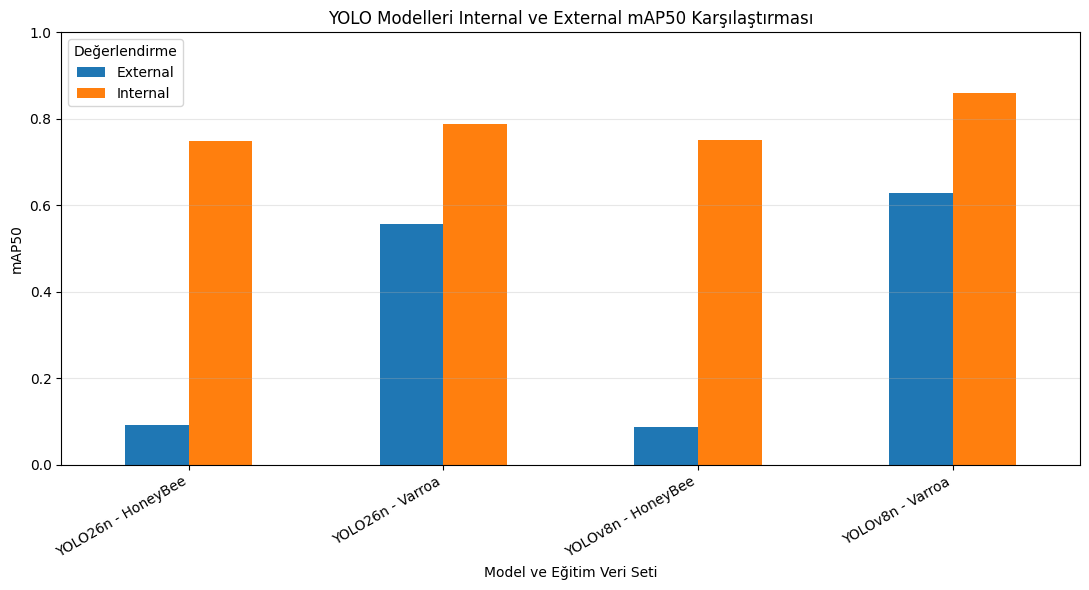

In [ ]:
pivot_map50 = df_yolo.pivot(
    index="Model_Dataset",
    columns="Evaluation",
    values="mAP50"
)

ax = pivot_map50.plot(kind="bar", figsize=(11, 6))

plt.title("YOLO Modelleri Internal ve External mAP50 Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("mAP50")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

plt.savefig(f"{GRAPH_DIR}/yolo_map50_comparison.png", dpi=300)
plt.show()

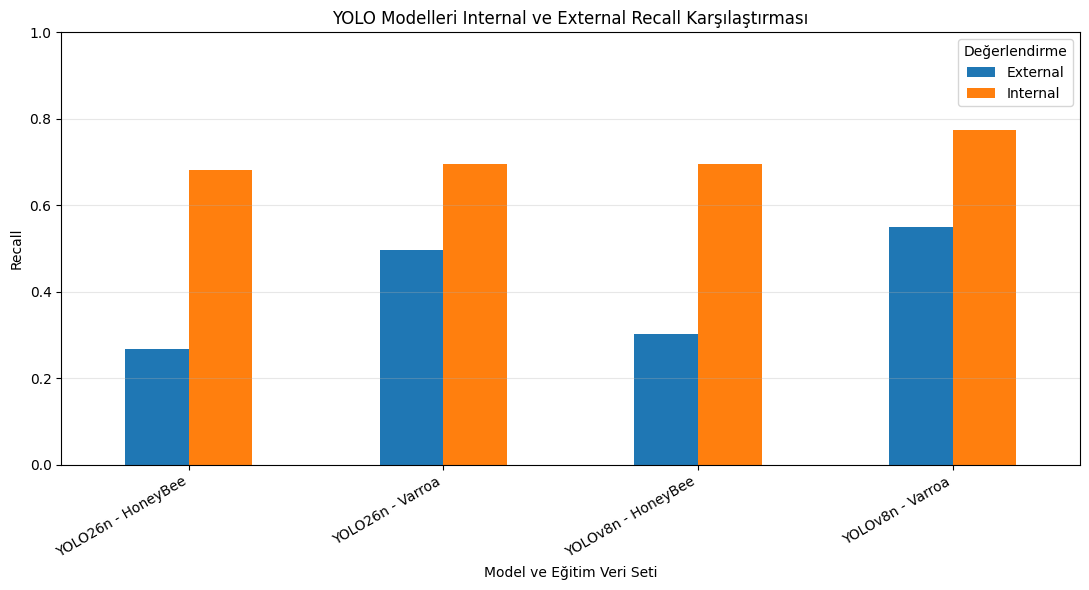

In [ ]:
pivot_recall = df_yolo.pivot(
    index="Model_Dataset",
    columns="Evaluation",
    values="Recall"
)

ax = pivot_recall.plot(kind="bar", figsize=(11, 6))

plt.title("YOLO Modelleri Internal ve External Recall Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

plt.savefig(f"{GRAPH_DIR}/yolo_recall_comparison.png", dpi=300)
plt.show()

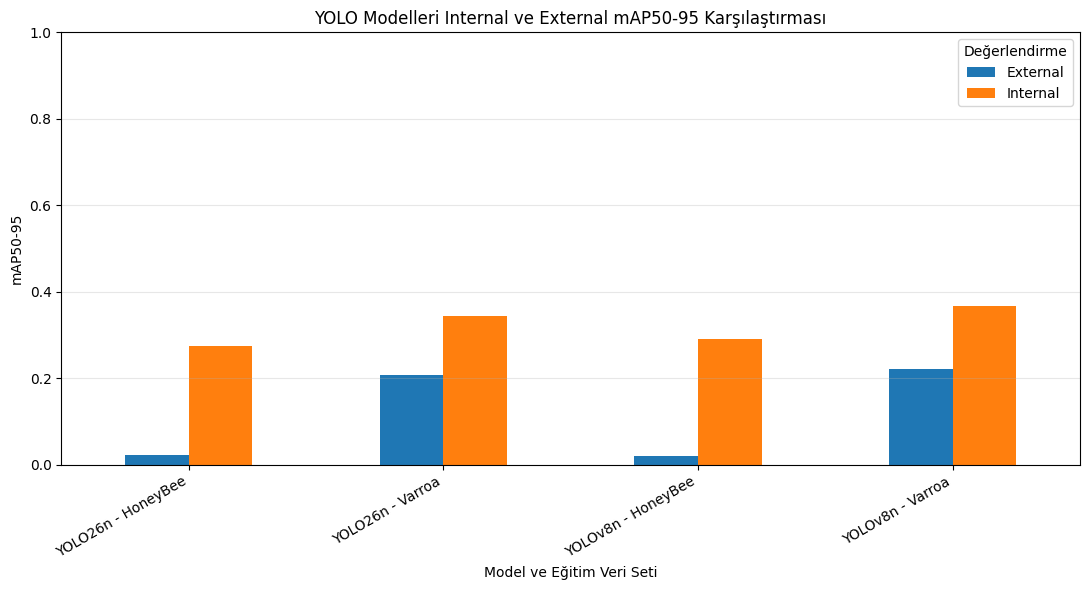

In [ ]:
pivot_map5095 = df_yolo.pivot(
    index="Model_Dataset",
    columns="Evaluation",
    values="mAP50-95"
)

ax = pivot_map5095.plot(kind="bar", figsize=(11, 6))

plt.title("YOLO Modelleri Internal ve External mAP50-95 Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("mAP50-95")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

plt.savefig(f"{GRAPH_DIR}/yolo_map50_95_comparison.png", dpi=300)
plt.show()

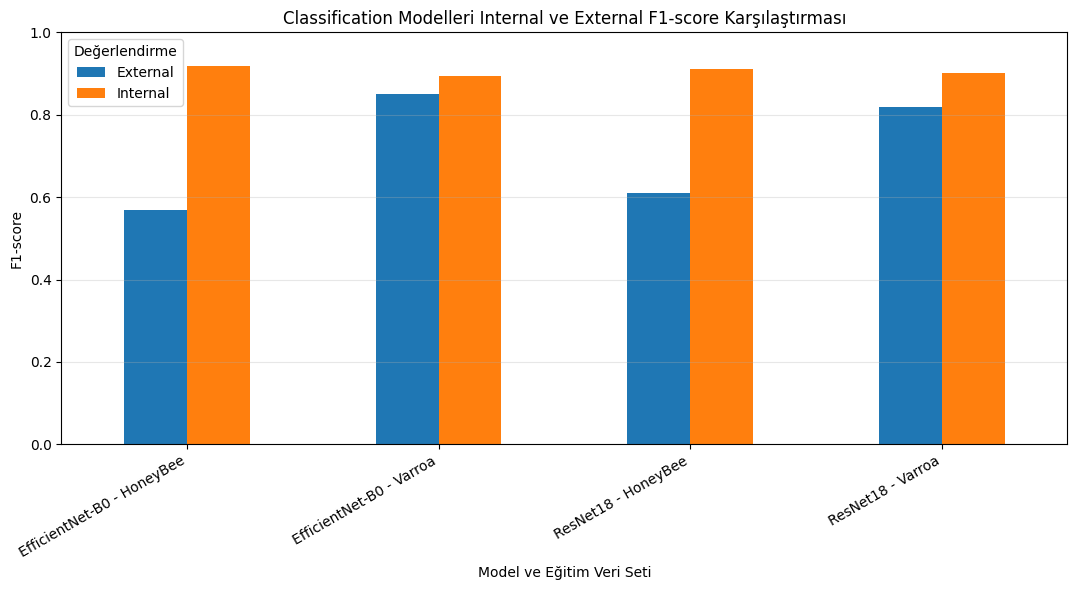

In [ ]:
pivot_f1 = df_cls.pivot(
    index="Model_Dataset",
    columns="Evaluation",
    values="F1-score"
)

ax = pivot_f1.plot(kind="bar", figsize=(11, 6))

plt.title("Classification Modelleri Internal ve External F1-score Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

plt.savefig(f"{GRAPH_DIR}/classification_f1_comparison.png", dpi=300)
plt.show()

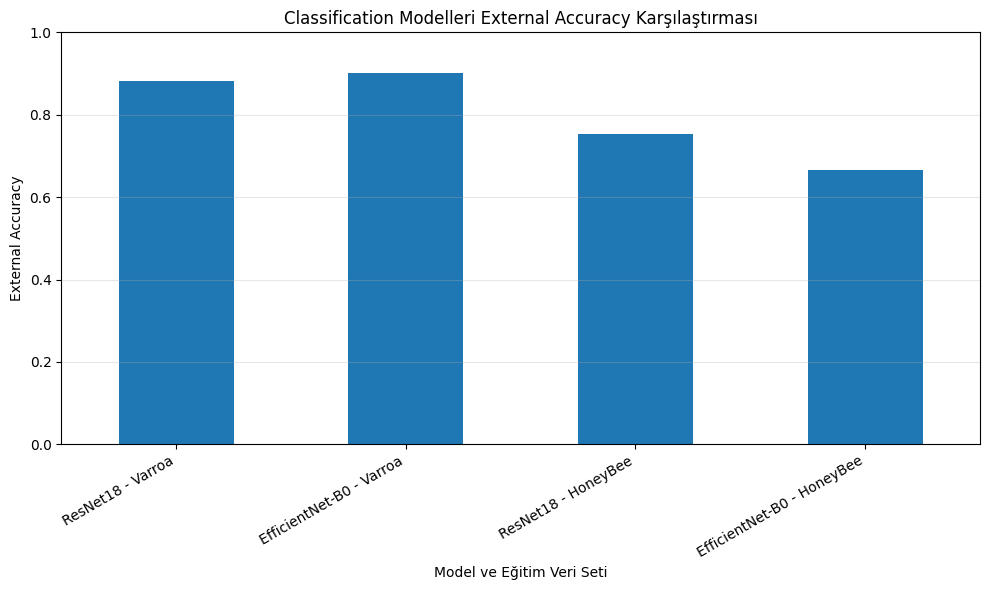

In [ ]:
external_cls = df_cls[df_cls["Evaluation"] == "External"].copy()
external_cls = external_cls.set_index("Model_Dataset")

ax = external_cls["Accuracy"].plot(kind="bar", figsize=(10, 6))

plt.title("Classification Modelleri External Accuracy Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("External Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(f"{GRAPH_DIR}/classification_external_accuracy.png", dpi=300)
plt.show()

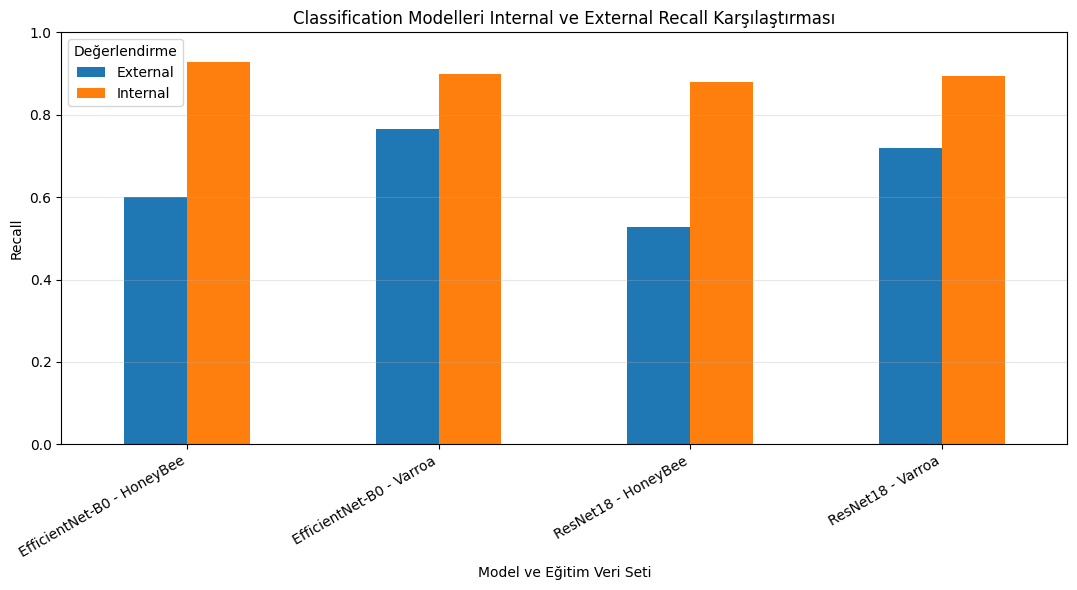

In [ ]:
pivot_cls_recall = df_cls.pivot(
    index="Model_Dataset",
    columns="Evaluation",
    values="Recall"
)

ax = pivot_cls_recall.plot(kind="bar", figsize=(11, 6))

plt.title("Classification Modelleri Internal ve External Recall Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

plt.savefig(f"{GRAPH_DIR}/classification_recall_comparison.png", dpi=300)
plt.show()

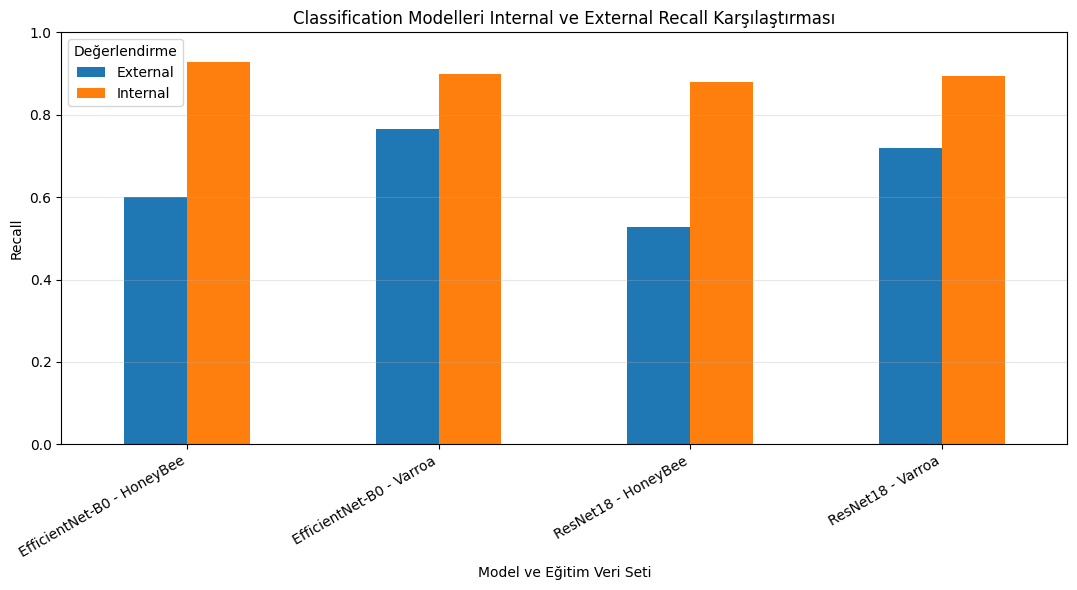

In [ ]:
pivot_cls_recall = df_cls.pivot(
    index="Model_Dataset",
    columns="Evaluation",
    values="Recall"
)

ax = pivot_cls_recall.plot(kind="bar", figsize=(11, 6))

plt.title("Classification Modelleri Internal ve External Recall Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

plt.savefig(f"{GRAPH_DIR}/classification_recall_comparison.png", dpi=300)
plt.show()

In [ ]:
import shutil
from google.colab import files

zip_path = "/content/varroa_graphs.zip"

shutil.make_archive(
    base_name="/content/varroa_graphs",
    format="zip",
    root_dir=GRAPH_DIR
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

excel_path = "/content/varroa_sonuc_tablolari.xlsx"

with pd.ExcelWriter(excel_path) as writer:
    df_yolo.to_excel(writer, sheet_name="YOLO Results", index=False)
    df_cls.to_excel(writer, sheet_name="Classification Results", index=False)

files.download(excel_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

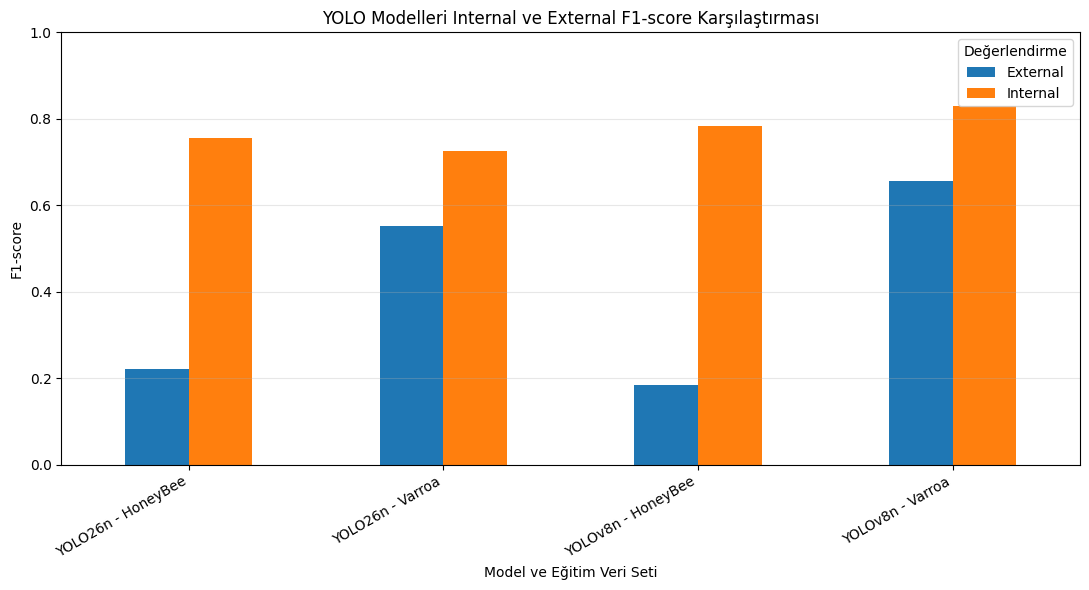

Grafik kaydedildi: /content/varroa_graphs/yolo_f1_comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Grafiklerin kaydedileceği klasör
GRAPH_DIR = "/content/varroa_graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

# YOLO F1-score verileri
yolo_f1_data = [
    ["YOLOv8n - Varroa", "Internal", 0.829],
    ["YOLOv8n - Varroa", "External", 0.657],
    ["YOLO26n - Varroa", "Internal", 0.725],
    ["YOLO26n - Varroa", "External", 0.553],
    ["YOLOv8n - HoneyBee", "Internal", 0.783],
    ["YOLOv8n - HoneyBee", "External", 0.185],
    ["YOLO26n - HoneyBee", "Internal", 0.756],
    ["YOLO26n - HoneyBee", "External", 0.222],
]

df_yolo_f1 = pd.DataFrame(
    yolo_f1_data,
    columns=["Model_Dataset", "Evaluation", "F1-score"]
)

pivot_yolo_f1 = df_yolo_f1.pivot(
    index="Model_Dataset",
    columns="Evaluation",
    values="F1-score"
)

ax = pivot_yolo_f1.plot(kind="bar", figsize=(11, 6))

plt.title("YOLO Modelleri Internal ve External F1-score Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

save_path = f"{GRAPH_DIR}/yolo_f1_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Grafik kaydedildi:", save_path)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/varroa_bitirme"
FINAL_GRAPH_DIR = f"{PROJECT_DIR}/final_report_graphs"

os.makedirs(FINAL_GRAPH_DIR, exist_ok=True)

print("Grafikler buraya kaydedilecek:")
print(FINAL_GRAPH_DIR)

Grafikler buraya kaydedilecek:
/content/drive/MyDrive/varroa_bitirme/final_report_graphs


In [ ]:
results_data = [
    # Geleneksel ML - Classification
    {
        "Model_Ailesi": "Geleneksel ML",
        "Gorev": "Classification",
        "Model": "SVM",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "F1-score",
        "Internal": 0.94,
        "External": 0.94
    },
    {
        "Model_Ailesi": "Geleneksel ML",
        "Gorev": "Classification",
        "Model": "SVM",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "F1-score",
        "Internal": 0.92,
        "External": 0.75
    },
    {
        "Model_Ailesi": "Geleneksel ML",
        "Gorev": "Classification",
        "Model": "Random Forest",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "F1-score",
        "Internal": 0.92,
        "External": None
    },
    {
        "Model_Ailesi": "Geleneksel ML",
        "Gorev": "Classification",
        "Model": "Random Forest",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "F1-score",
        "Internal": 0.91,
        "External": 0.78
    },

    # Geleneksel ML - Detection
    {
        "Model_Ailesi": "Geleneksel ML",
        "Gorev": "Detection",
        "Model": "SVM",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "F1@IoU0.20",
        "Internal": 0.39,
        "External": 0.43
    },
    {
        "Model_Ailesi": "Geleneksel ML",
        "Gorev": "Detection",
        "Model": "Random Forest",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "F1@IoU0.20",
        "Internal": 0.53,
        "External": 0.23
    },

    # CNN - Classification
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Classification",
        "Model": "ResNet18",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "F1-score",
        "Internal": 0.9007,
        "External": 0.8177
    },
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Classification",
        "Model": "ResNet18",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "F1-score",
        "Internal": 0.9109,
        "External": 0.6101
    },
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Classification",
        "Model": "EfficientNet-B0",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "F1-score",
        "Internal": 0.8928,
        "External": 0.8499
    },
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Classification",
        "Model": "EfficientNet-B0",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "F1-score",
        "Internal": 0.9178,
        "External": 0.5696
    },

    # CNN - Detection
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Detection",
        "Model": "YOLOv8n",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "mAP50",
        "Internal": 0.8600,
        "External": 0.6290
    },
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Detection",
        "Model": "YOLOv8n",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "mAP50",
        "Internal": 0.7500,
        "External": 0.0885
    },
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Detection",
        "Model": "YOLO26n",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "mAP50",
        "Internal": 0.7870,
        "External": 0.5570
    },
    {
        "Model_Ailesi": "CNN",
        "Gorev": "Detection",
        "Model": "YOLO26n",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "mAP50",
        "Internal": 0.7480,
        "External": 0.0930
    },

    # Transformer - Detection
    {
        "Model_Ailesi": "Transformer",
        "Gorev": "Detection",
        "Model": "DETR",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "mAP50",
        "Internal": 0.4964,
        "External": 0.3540
    },
    {
        "Model_Ailesi": "Transformer",
        "Gorev": "Detection",
        "Model": "Deformable DETR",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "mAP50",
        "Internal": 0.8650,
        "External": 0.6980
    },
    {
        "Model_Ailesi": "Transformer",
        "Gorev": "Detection",
        "Model": "Deformable DETR",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "mAP50",
        "Internal": 0.3905,
        "External": 0.2315
    },
    {
        "Model_Ailesi": "Transformer",
        "Gorev": "Detection",
        "Model": "RT-DETR",
        "Egitim_Veri_Seti": "Varroa Dataset",
        "Ana_Metrik": "mAP50",
        "Internal": 0.8446,
        "External": 0.7120
    },
    {
        "Model_Ailesi": "Transformer",
        "Gorev": "Detection",
        "Model": "RT-DETR",
        "Egitim_Veri_Seti": "HoneyBee VarroaMite",
        "Ana_Metrik": "mAP50",
        "Internal": 0.8448,
        "External": 0.6780
    },
]

df_results = pd.DataFrame(results_data)
df_results["Performans_Kaybi"] = df_results["Internal"] - df_results["External"]

csv_path = f"{FINAL_GRAPH_DIR}/tum_modeller_genel_sonuc_tablosu.csv"
df_results.to_csv(csv_path, index=False, encoding="utf-8-sig")

df_results

,Model_Ailesi,Gorev,Model,Egitim_Veri_Seti,Ana_Metrik,Internal,External,Performans_Kaybi
0,Geleneksel ML,Classification,SVM,Varroa Dataset,F1-score,0.9400,0.9400,0.0000
1,Geleneksel ML,Classification,SVM,HoneyBee VarroaMite,F1-score,0.9200,0.7500,0.1700
2,Geleneksel ML,Classification,Random Forest,Varroa Dataset,F1-score,0.9200,NaN,NaN
3,Geleneksel ML,Classification,Random Forest,HoneyBee VarroaMite,F1-score,0.9100,0.7800,0.1300
4,Geleneksel ML,Detection,SVM,Varroa Dataset,F1@IoU0.20,0.3900,0.4300,-0.0400
5,Geleneksel ML,Detection,Random Forest,HoneyBee VarroaMite,F1@IoU0.20,0.5300,0.2300,0.3000
6,CNN,Classification,ResNet18,Varroa Dataset,F1-score,0.9007,0.8177,0.0830
7,CNN,Classification,ResNet18,HoneyBee VarroaMite,F1-score,0.9109,0.6101,0.3008
8,CNN,Classification,EfficientNet-B0,Varroa Dataset,F1-score,0.8928,0.8499,0.0429
9,CNN,Classification,EfficientNet-B0,HoneyBee VarroaMite,F1-score,0.9178,0.5696,0.3482


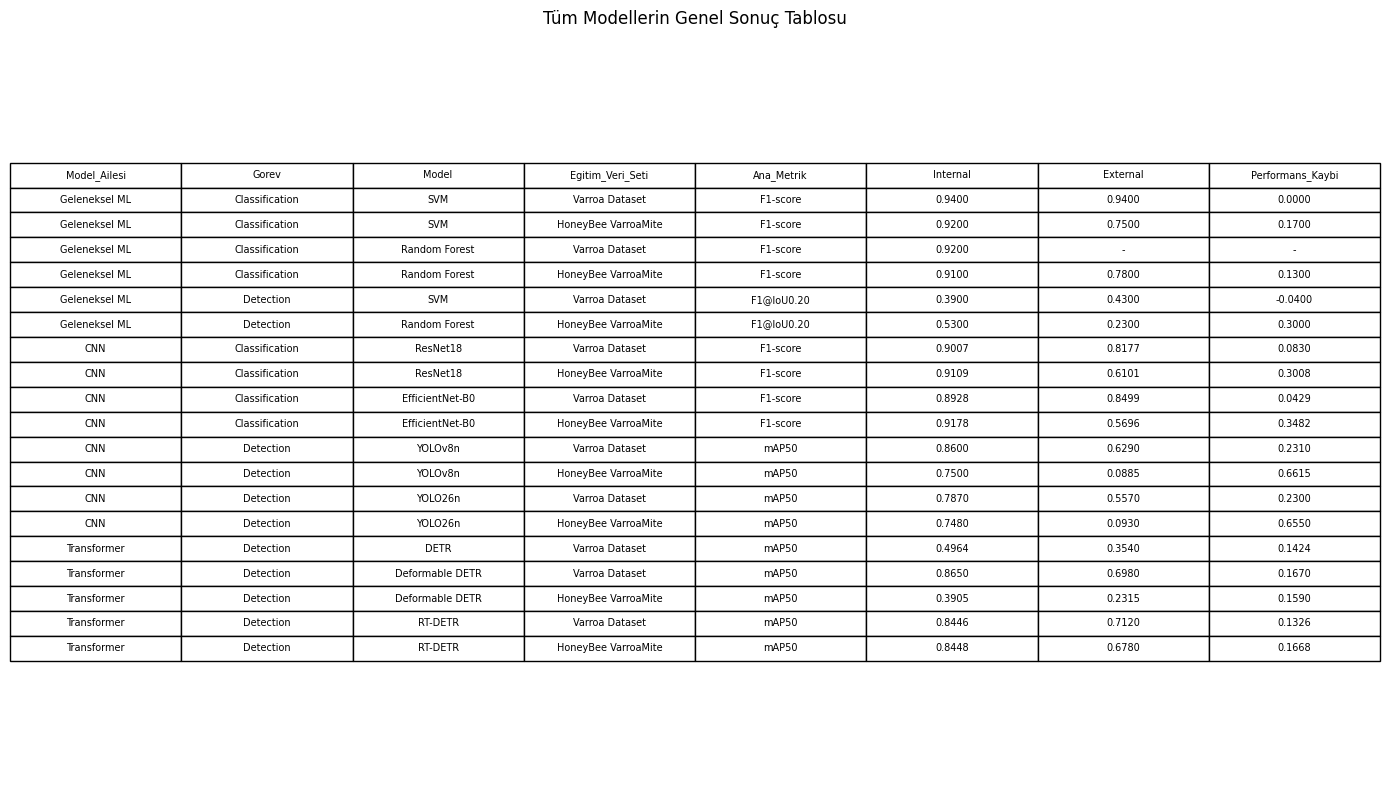

Kaydedildi: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/tum_modeller_genel_sonuc_tablosu.png


In [ ]:
table_df = df_results.copy()

for col in ["Internal", "External", "Performans_Kaybi"]:
    table_df[col] = table_df[col].apply(lambda x: "-" if pd.isna(x) else f"{x:.4f}")

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1, 1.25)

plt.title("Tüm Modellerin Genel Sonuç Tablosu", pad=14)
plt.tight_layout()

save_path = f"{FINAL_GRAPH_DIR}/tum_modeller_genel_sonuc_tablosu.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", save_path)

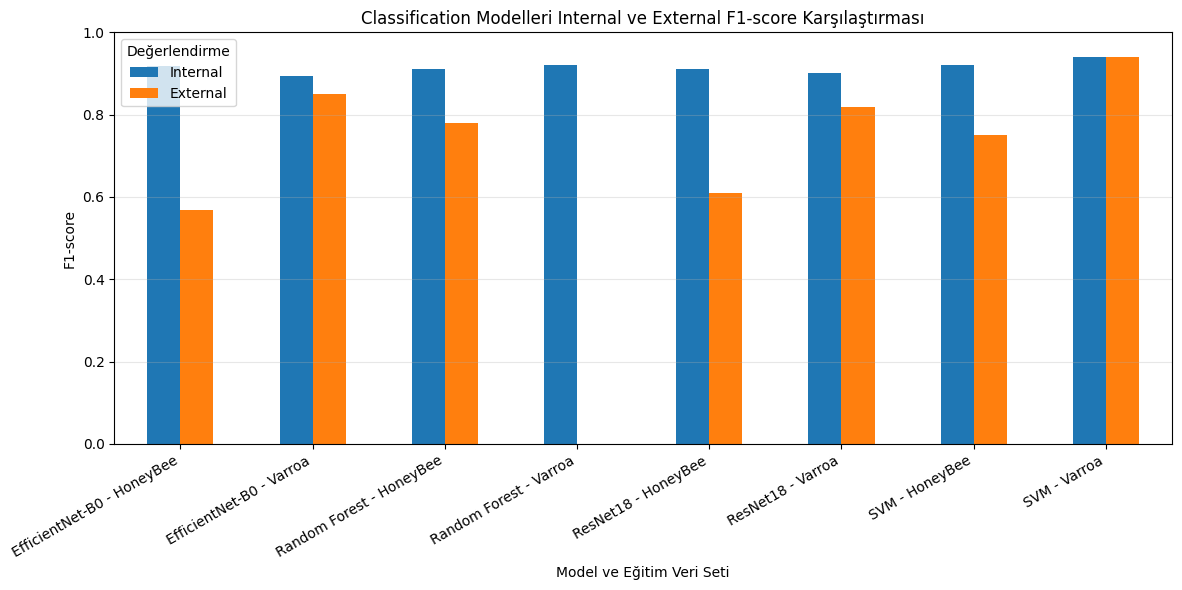

Kaydedildi: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/genel_classification_f1_karsilastirma.png


In [ ]:
df_cls = df_results[
    (df_results["Gorev"] == "Classification") &
    (df_results["Ana_Metrik"] == "F1-score")
].copy()

df_cls["Model_Dataset"] = (
    df_cls["Model"] + " - " +
    df_cls["Egitim_Veri_Seti"].replace({
        "Varroa Dataset": "Varroa",
        "HoneyBee VarroaMite": "HoneyBee"
    })
)

plot_df = df_cls.pivot_table(
    index="Model_Dataset",
    values=["Internal", "External"],
    aggfunc="first"
)

ax = plot_df[["Internal", "External"]].plot(kind="bar", figsize=(12, 6))

plt.title("Classification Modelleri Internal ve External F1-score Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

save_path = f"{FINAL_GRAPH_DIR}/genel_classification_f1_karsilastirma.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", save_path)

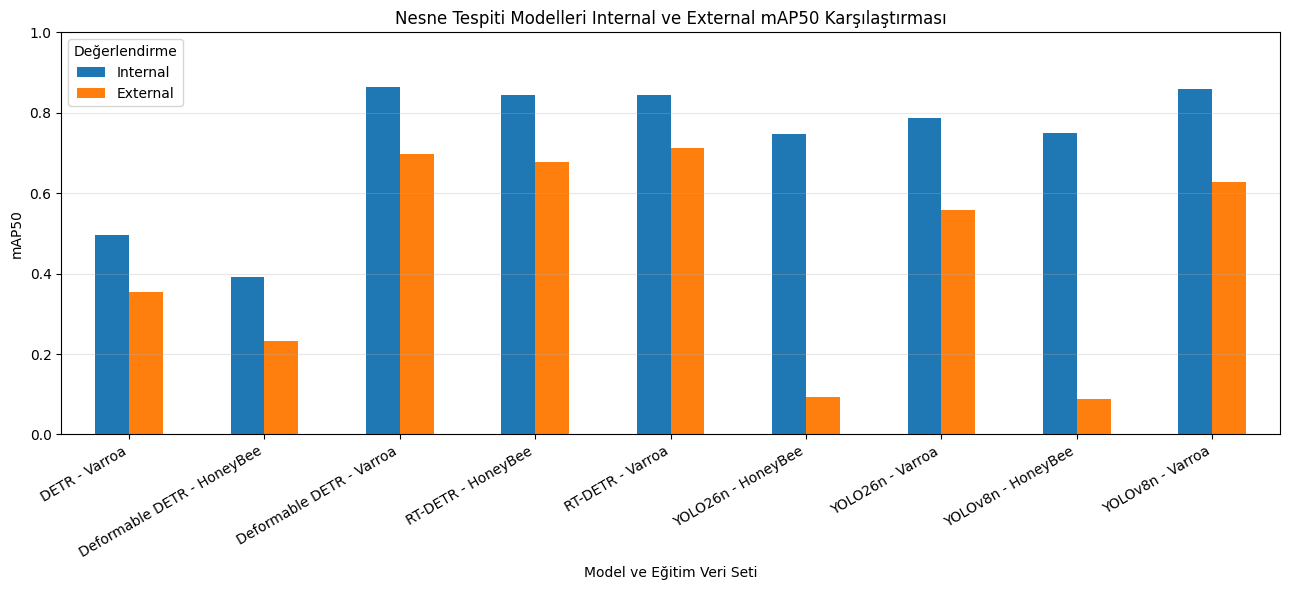

Kaydedildi: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/genel_detection_map50_karsilastirma.png


In [ ]:
df_det_map50 = df_results[
    (df_results["Gorev"] == "Detection") &
    (df_results["Ana_Metrik"] == "mAP50")
].copy()

df_det_map50["Model_Dataset"] = (
    df_det_map50["Model"] + " - " +
    df_det_map50["Egitim_Veri_Seti"].replace({
        "Varroa Dataset": "Varroa",
        "HoneyBee VarroaMite": "HoneyBee"
    })
)

plot_df = df_det_map50.pivot_table(
    index="Model_Dataset",
    values=["Internal", "External"],
    aggfunc="first"
)

ax = plot_df[["Internal", "External"]].plot(kind="bar", figsize=(13, 6))

plt.title("Nesne Tespiti Modelleri Internal ve External mAP50 Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("mAP50")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

save_path = f"{FINAL_GRAPH_DIR}/genel_detection_map50_karsilastirma.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", save_path)

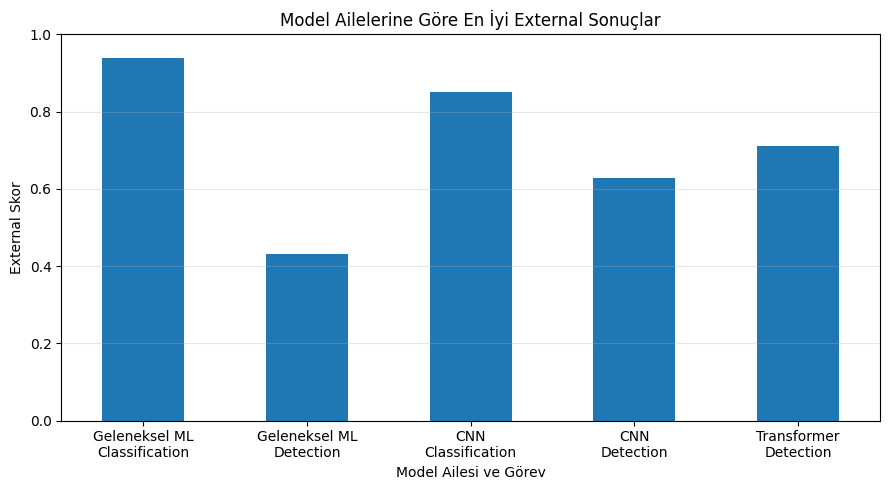

Kaydedildi: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/model_aileleri_en_iyi_external_ozet.png
CSV: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/model_aileleri_en_iyi_external_ozet.csv


,Model_Ailesi_Gorev,En_Iyi_Model,Metrik,External_Skor
0,Geleneksel ML\nClassification,SVM - Varroa,F1-score,0.9400
1,Geleneksel ML\nDetection,SVM - Varroa,F1@IoU0.20,0.4300
2,CNN\nClassification,EfficientNet-B0 - Varroa,F1-score,0.8499
3,CNN\nDetection,YOLOv8n - Varroa,mAP50,0.6290
4,Transformer\nDetection,RT-DETR - Varroa,mAP50,0.7120


In [ ]:
best_external_data = [
    {
        "Model_Ailesi_Gorev": "Geleneksel ML\nClassification",
        "En_Iyi_Model": "SVM - Varroa",
        "Metrik": "F1-score",
        "External_Skor": 0.94
    },
    {
        "Model_Ailesi_Gorev": "Geleneksel ML\nDetection",
        "En_Iyi_Model": "SVM - Varroa",
        "Metrik": "F1@IoU0.20",
        "External_Skor": 0.43
    },
    {
        "Model_Ailesi_Gorev": "CNN\nClassification",
        "En_Iyi_Model": "EfficientNet-B0 - Varroa",
        "Metrik": "F1-score",
        "External_Skor": 0.8499
    },
    {
        "Model_Ailesi_Gorev": "CNN\nDetection",
        "En_Iyi_Model": "YOLOv8n - Varroa",
        "Metrik": "mAP50",
        "External_Skor": 0.629
    },
    {
        "Model_Ailesi_Gorev": "Transformer\nDetection",
        "En_Iyi_Model": "RT-DETR - Varroa",
        "Metrik": "mAP50",
        "External_Skor": 0.712
    },
]

df_best_external = pd.DataFrame(best_external_data)

csv_path = f"{FINAL_GRAPH_DIR}/model_aileleri_en_iyi_external_ozet.csv"
df_best_external.to_csv(csv_path, index=False, encoding="utf-8-sig")

ax = df_best_external.set_index("Model_Ailesi_Gorev")["External_Skor"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Ailelerine Göre En İyi External Sonuçlar")
plt.xlabel("Model Ailesi ve Görev")
plt.ylabel("External Skor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_path = f"{FINAL_GRAPH_DIR}/model_aileleri_en_iyi_external_ozet.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", save_path)
print("CSV:", csv_path)

df_best_external

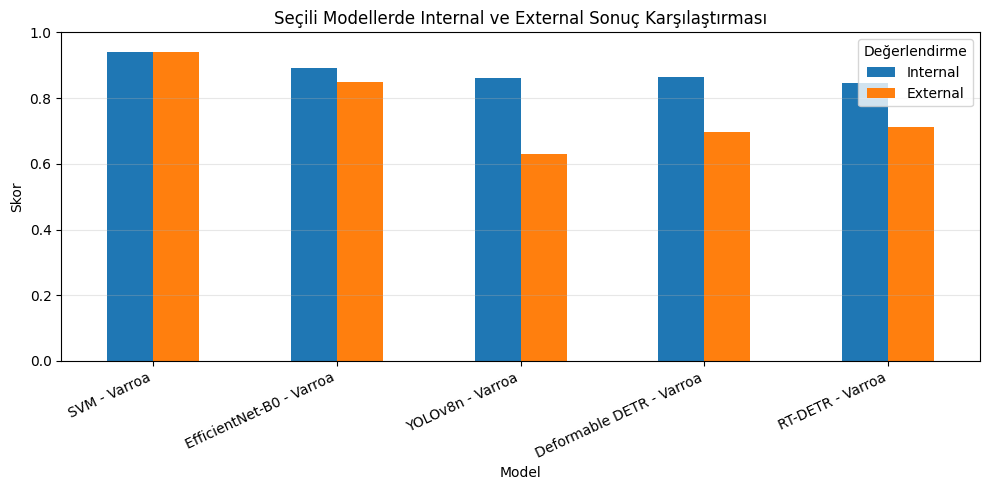

Kaydedildi: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/internal_external_secili_modeller_karsilastirma.png
CSV: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/internal_external_fark_secili_modeller.csv


,Model,Metrik,Internal,External,Performans_Kaybi
0,SVM - Varroa,Classification F1,0.9400,0.9400,0.0000
1,EfficientNet-B0 - Varroa,Classification F1,0.8928,0.8499,0.0429
2,YOLOv8n - Varroa,Detection mAP50,0.8600,0.6290,0.2310
3,Deformable DETR - Varroa,Detection mAP50,0.8650,0.6980,0.1670
4,RT-DETR - Varroa,Detection mAP50,0.8446,0.7120,0.1326


In [ ]:
gap_data = [
    {
        "Model": "SVM - Varroa",
        "Metrik": "Classification F1",
        "Internal": 0.94,
        "External": 0.94
    },
    {
        "Model": "EfficientNet-B0 - Varroa",
        "Metrik": "Classification F1",
        "Internal": 0.8928,
        "External": 0.8499
    },
    {
        "Model": "YOLOv8n - Varroa",
        "Metrik": "Detection mAP50",
        "Internal": 0.8600,
        "External": 0.6290
    },
    {
        "Model": "Deformable DETR - Varroa",
        "Metrik": "Detection mAP50",
        "Internal": 0.8650,
        "External": 0.6980
    },
    {
        "Model": "RT-DETR - Varroa",
        "Metrik": "Detection mAP50",
        "Internal": 0.8446,
        "External": 0.7120
    },
]

df_gap = pd.DataFrame(gap_data)
df_gap["Performans_Kaybi"] = df_gap["Internal"] - df_gap["External"]

csv_path = f"{FINAL_GRAPH_DIR}/internal_external_fark_secili_modeller.csv"
df_gap.to_csv(csv_path, index=False, encoding="utf-8-sig")

plot_df = df_gap.set_index("Model")[["Internal", "External"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Seçili Modellerde Internal ve External Sonuç Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Skor")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

save_path = f"{FINAL_GRAPH_DIR}/internal_external_secili_modeller_karsilastirma.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", save_path)
print("CSV:", csv_path)

df_gap

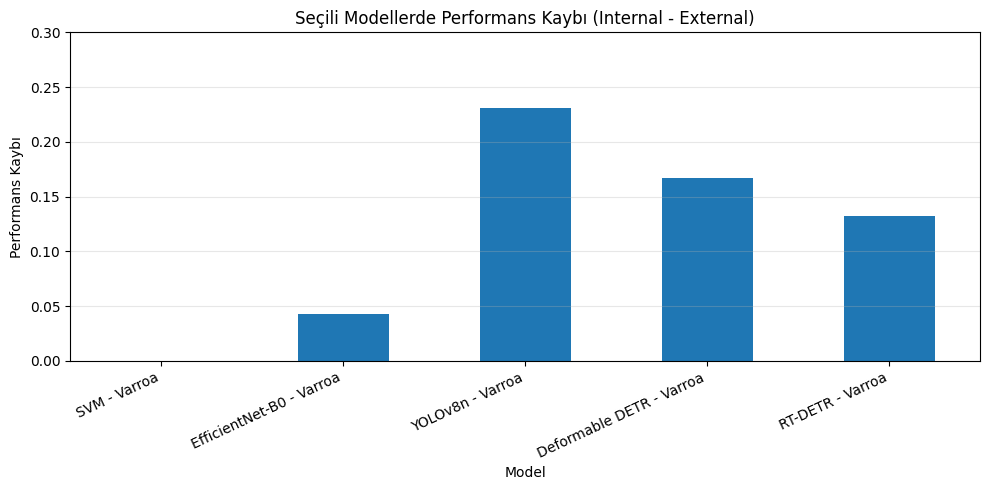

Kaydedildi: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/internal_external_performans_kaybi.png


In [ ]:
ax = df_gap.set_index("Model")["Performans_Kaybi"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Seçili Modellerde Performans Kaybı (Internal - External)")
plt.xlabel("Model")
plt.ylabel("Performans Kaybı")
plt.ylim(0, max(0.30, df_gap["Performans_Kaybi"].max() + 0.05))
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_path = f"{FINAL_GRAPH_DIR}/internal_external_performans_kaybi.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", save_path)

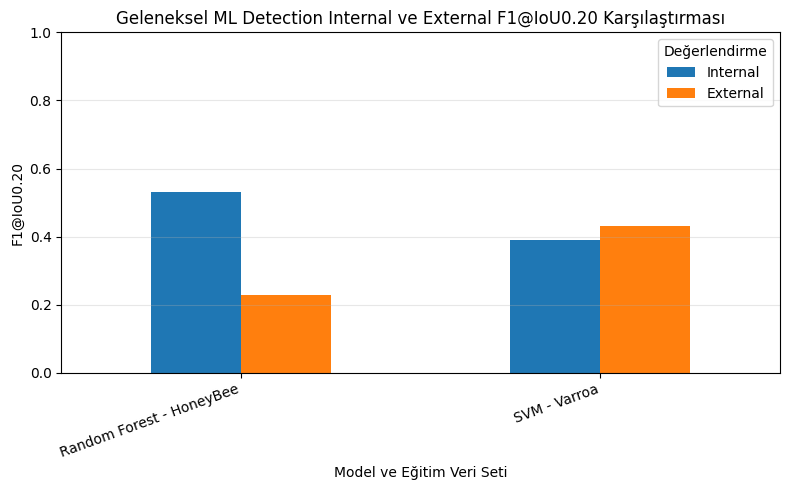

Kaydedildi: /content/drive/MyDrive/varroa_bitirme/final_report_graphs/geleneksel_ml_detection_f1_iou020_karsilastirma.png


In [ ]:
df_trad_det = df_results[
    (df_results["Model_Ailesi"] == "Geleneksel ML") &
    (df_results["Gorev"] == "Detection")
].copy()

df_trad_det["Model_Dataset"] = (
    df_trad_det["Model"] + " - " +
    df_trad_det["Egitim_Veri_Seti"].replace({
        "Varroa Dataset": "Varroa",
        "HoneyBee VarroaMite": "HoneyBee"
    })
)

plot_df = df_trad_det.pivot_table(
    index="Model_Dataset",
    values=["Internal", "External"],
    aggfunc="first"
)

ax = plot_df[["Internal", "External"]].plot(kind="bar", figsize=(8, 5))

plt.title("Geleneksel ML Detection Internal ve External F1@IoU0.20 Karşılaştırması")
plt.xlabel("Model ve Eğitim Veri Seti")
plt.ylabel("F1@IoU0.20")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Değerlendirme")
plt.tight_layout()

save_path = f"{FINAL_GRAPH_DIR}/geleneksel_ml_detection_f1_iou020_karsilastirma.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", save_path)

In [ ]:
import os

for file_name in sorted(os.listdir(FINAL_GRAPH_DIR)):
    print(file_name)

geleneksel_ml_detection_f1_iou020_karsilastirma.png
genel_classification_f1_karsilastirma.png
genel_detection_map50_karsilastirma.png
internal_external_fark_secili_modeller.csv
internal_external_performans_kaybi.png
internal_external_secili_modeller_karsilastirma.png
model_aileleri_en_iyi_external_ozet.csv
model_aileleri_en_iyi_external_ozet.png
tum_modeller_genel_sonuc_tablosu.csv
tum_modeller_genel_sonuc_tablosu.png
